# XGBoost (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with XGBoost](#6-implementation-with-xgboost)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)

> **Scope**: `src/models/` has no XGBoost-specific twin. It implements the **gradient boosting skeleton** that XGBoost is built on — `GradientBoostingClassifierScratch` in `src/models/ensemble_models.py` (notebook 08). Section 5 tours that twin and hand-builds XGBoost's λ-regularized leaf values from it; the native XGBoost API and regression with `XGBRegressor` stay library-only (§6).

---

## 1. Introduction

**XGBoost** takes the gradient boosting skeleton of notebook 08 — an additive model $F_m = F_{m-1} + \nu\,h_m$ whose stages fit pseudo-residuals — and rebuilds every part of it for accuracy, robustness, and speed. Its contribution is a **regularized, second-order formulation** of boosting: each stage's tree is grown to minimize an objective that carries the loss's **curvature** (the hessian) *and* an explicit complexity penalty $\Omega$, so every leaf value and every split is priced, not just fitted.

**Key characteristics:**

- **Second-order**: leaf values are Newton steps $-G / (H + \lambda)$, computed from first and second derivatives of the loss — not just the gradient (notebook 08 §2 behind the formula)
- **Regularized**: $\Omega = \gamma T + \frac{1}{2}\lambda \sum_j w_j^2$ penalizes the number of leaves $T$ and the size of every leaf weight $w_j$; a split must repay a minimum gain $\gamma$ to happen at all
- **Sparsity-aware**: missing values are routed natively — each feature *learns* which branch NaNs should follow, no imputation required
- **Histogram splits**: feature values are binned into candidate thresholds (up to `max_bin`), which makes split search fast and independent of candidate-count $n$
- **Engineering**: parallel threads, GPU support (`device`), early stopping, compression-aware caching, and well-understood defaults; winner of tabular benchmarks for a decade

**Historical Context:**

- Friedman (2001): gradient boosting — the skeleton (notebook 08)
- Friedman (2002): *stochastic* gradient boosting — row subsampling, `subsample`
- Chen & Guestrin (2016): **XGBoost: A Scalable Tree Boosting System** (*KDD*) — the regularized second-order objective, sparsity-aware splits, weighted-quantile split proposals, and the systems engineering
- The idea is also the template for the follow-ups: LightGBM and CatBoost (notebooks 10–11)

**Main Use Cases:**

- Tabular classification and regression where accuracy is the priority (§4, §11)
- Robust feature handling: missing values, mixed scales, outliers — with careful tuning
- Competition and production workloads: GPU path, early stopping, and serialization are first-class

**How it works (simplified):**

1. Start from an initial guess $F_0$ (automatically estimated from the labels in XGBoost 3.x)
2. Form the first- and second-order loss terms $g_i, h_i$ at the current prediction (§2)
3. Grow a small tree whose splits maximize the **regularized gain** and whose leaves take the values $w_j^* = -G_j / (H_j + \lambda)$
4. Add the tree, scaled by the learning rate $\nu$ (alias `eta`)
5. Stop when the stage budget is hit or a validation metric stops improving (early stopping)

In [1]:
# Import necessary libraries
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

from sklearn.datasets import load_breast_cancer, load_diabetes, make_blobs, make_moons
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, mean_squared_error, r2_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version:   {np.__version__}")
print(f"Pandas version:  {pd.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"\nDocumented against the pinned versions in uv.lock: xgboost {xgb.__version__}, scikit-learn 1.9")

Libraries imported successfully!
NumPy version:   2.5.1
Pandas version:  3.0.3
XGBoost version: 3.3.0

Documented against the pinned versions in uv.lock: xgboost 3.3.0, scikit-learn 1.9


### Visual Intuition: λ Draws the Line

The skeleton (notebook 08) decides *what* each stage fits; the regularizer Ω decides *how far away from zero* each leaf may go. A single sweep of `reg_lambda` (alias `lambda`) on identical fits makes the effect visible:

- **λ = 1 (XGBoost's default)**: moderate shrinkage; the probability field develops sharp ridges between the classes
- **λ = 10**: every leaf weight is pulled toward zero, so the field softens — sharper still where the data is unambiguous
- **λ = 100**: extreme shrinkage; each leaf carries almost no mass and the field collapses toward the base rate — the underfit face of the same knob that combats overfitting

The learning rate $\nu$ and the stage count stay fixed; only Ω moves.

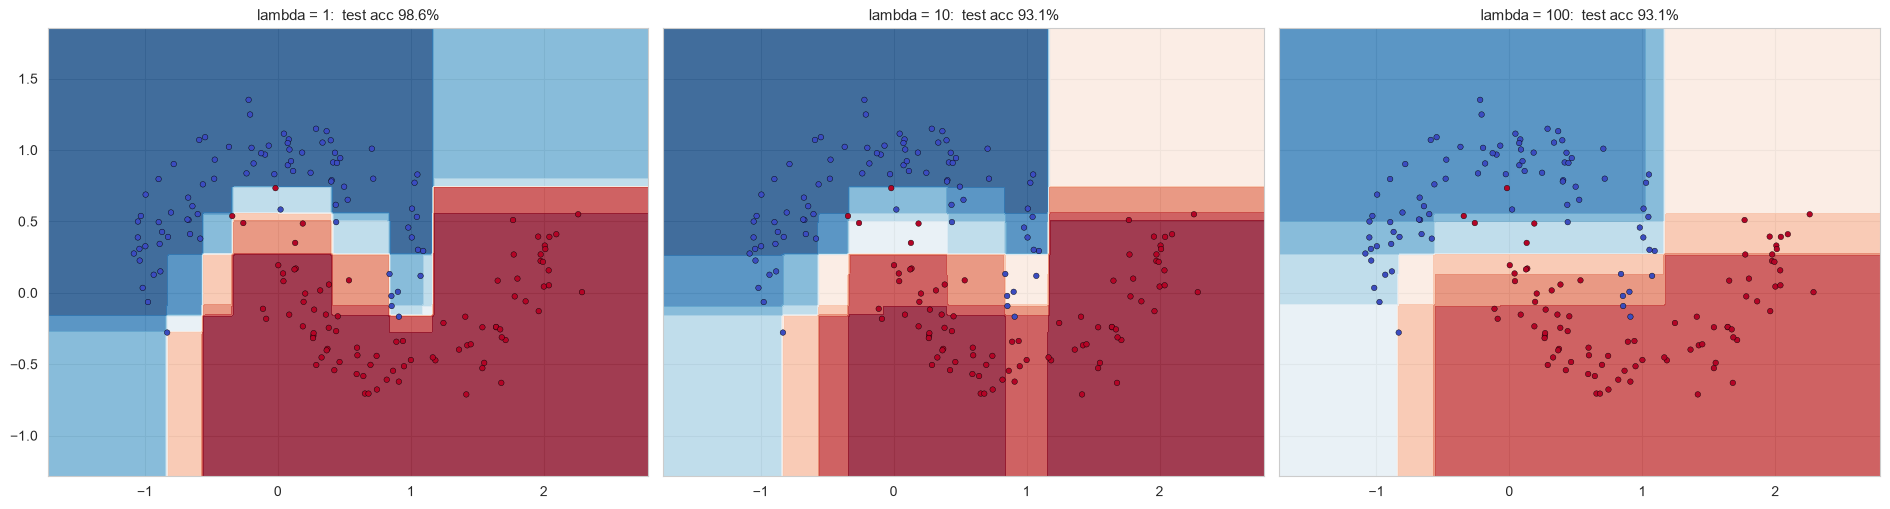

💡 reg_lambda is the strength of the 1/2 * lambda * sum(w^2) term in the objective.
   Every leaf weight is pushed toward zero slightly, so a heavily-regularized model
   needs more stages to recover — and under-regularization is what lets boosting
   carve memorizing islands around single training points.


In [2]:
# Three fits on the same moons split, differing ONLY in reg_lambda
Xm_v, ym_v = make_moons(n_samples=240, noise=0.15, random_state=0)
Xmv_tr, Xmv_te, ymv_tr, ymv_te = train_test_split(Xm_v, ym_v, test_size=0.3, random_state=42)

lam_values = [1.0, 10.0, 100.0]
xgb_models_v = []
for lam_v in lam_values:
    m_v = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=2,
                        reg_lambda=lam_v, random_state=42).fit(Xmv_tr, ymv_tr)
    xgb_models_v.append(m_v)

pad_v = 0.5
xx_v, yy_v = np.meshgrid(
    np.linspace(Xm_v[:, 0].min() - pad_v, Xm_v[:, 0].max() + pad_v, 220),
    np.linspace(Xm_v[:, 1].min() - pad_v, Xm_v[:, 1].max() + pad_v, 220),
)
grid_pts_v = np.c_[xx_v.ravel(), yy_v.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2), sharey=True)
for ax, m_v, lam_v in zip(axes, xgb_models_v, lam_values):
    field_v = m_v.predict_proba(grid_pts_v)[:, 1].reshape(xx_v.shape)
    ax.contourf(xx_v, yy_v, field_v, levels=np.linspace(0.0, 1.0, 11), cmap="RdBu_r", alpha=0.8)
    ax.scatter(Xmv_tr[:, 0], Xmv_tr[:, 1], c=ymv_tr, cmap="coolwarm", s=16,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"lambda = {lam_v:g}:  test acc {m_v.score(Xmv_te, ymv_te):.1%}", fontsize=11)
plt.tight_layout()
plt.show()

print("💡 reg_lambda is the strength of the 1/2 * lambda * sum(w^2) term in the objective.")
print("   Every leaf weight is pushed toward zero slightly, so a heavily-regularized model")
print("   needs more stages to recover — and under-regularization is what lets boosting")
print("   carve memorizing islands around single training points.")

---

## 2. Theory & Mathematics

### The Regularized Objective

Notebook 08 wrote boosting as gradient descent in function space: each stage descends the loss using its **first derivative**. XGBoost keeps a second-order Taylor expansion of the loss around the current prediction:

$$\mathrm{Obj}^{(m)} = \sum_{i=1}^{n}\Big[\underbrace{\ell\big(y_i, \hat{y}_{m-1,i}\big)}_{\text{constant at stage } m} + \; g_i\, f_m(x_i) + \tfrac{1}{2}\,h_i\, f_m(x_i)^2\Big] + \Omega(f_m)$$

with the first- and second-order terms evaluated at the current model:

$$g_i = \frac{\partial\, \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i}\bigg|_{\hat{y}_{m-1}} \qquad h_i = \frac{\partial^2\ell(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}\bigg|_{\hat{y}_{m-1}}$$

and the explicit complexity penalty

$$\Omega(f) = \gamma\, T + \tfrac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

where $T$ is the number of leaves and $w_j$ is leaf $j$'s score. Two regularizers, two distinct jobs: **$\gamma$ charges a toll per split** (the tree must justify its own shape), **$\lambda$ shrinks every leaf value** toward zero (each leaf must earn its mass against an $L_2$ price).

### From Objective to Leaf Weights, then to Split Gains

Group the samples by the leaf they fall into and the objective becomes a sum of *independent per-leaf problems* with closed form. Completing the square per leaf gives the optimal leaf value and the optimal objective:

$$w_j^* = -\frac{G_j}{H_j + \lambda} \qquad \mathrm{Obj}^* = -\tfrac{1}{2}\sum_{j=1}^{T}\frac{G_j^2}{H_j + \lambda} + \gamma\, T, \qquad G_j = \sum_{i \in \text{leaf } j} g_i, \;\; H_j = \sum_{i \in \text{leaf } j} h_i$$

The tree grows by valuing each candidate split with the identical machine:

$$\mathrm{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda}\right] - \gamma$$

Three facts are worth reading off this formula:

1. **$\lambda$ is a leaf-size smoother.** When a child carries almost no hessian mass ($H \to 0$), its unregularized score $G^2/H$ explodes; the $+\lambda$ calms that, so noisy minority leaves get small values instead of huge ones
2. **$\gamma$ is a minimum-gain toll.** A split only happens if its gain exceeds $\gamma$ — pruning behavior built into the split criterion, not a post-hoc step
3. **`min_child_weight` is the same idea in disguise.** The name is literal: a candidate child with $\sum h_i$ below `min_child_weight` is not split at all

### The Losses and Their Two Derivatives

Notebook 08's pseudo-residual table, extended with the curvature column the second-order machinery requires:

| Loss | $g_i$ (first order) | $h_i$ (second order) | Used for |
|---|---|---|---|
| Squared error $\tfrac{1}{2}(y - F)^2$ | $F - y$ | $1$ | regression (`reg:squarederror`) |
| Log-loss $-[y \log p + (1-y)\log(1-p)]$ | $p - y$ | $p\,(1-p)$ | binary classification (`binary:logistic`) |
| Softmax deviance (multiclass) | $p_k - y_k$ per class $k$ | $p_k\,(1-p_k)$ | K classes → K trees per stage |

This is the table notebook 08 promised: same losses, same residuals — plus the curvature column that the second-order machinery requires, and the regularization that lets each split decide honestly.

In [3]:
# A single leaf's five training samples (the same numbers as notebook 08's Newton demo),
# now under XGBoost's notation: g = dL/dF, h = d2L/dF2, for log-loss
p_leaf = np.array([0.90, 0.20, 0.40, 0.70, 0.60])   # current probabilities
y_leaf = np.array([1.0, 1.0, 0.0, 1.0, 0.0])        # true labels

g_leaf = p_leaf - y_leaf               # XGBoost's first-order term: p - y
h_leaf = p_leaf * (1.0 - p_leaf)       # its second-order term: p(1 - p)

G_leaf, H_leaf = g_leaf.sum(), h_leaf.sum()
print(f"label sums:  G = sum(g) = {G_leaf:+.4f}   H = sum(h) = {H_leaf:.4f}")

# The leaf value at lambda = 0 is EXACTLY notebook 08's Newton step (sum(y-p) / sum(p(1-p)))
w_star_lam0 = -G_leaf / (H_leaf + 0.0)
twin_newton = (y_leaf - p_leaf).sum() / h_leaf.sum()
print(f"w* at lambda = 0:        {w_star_lam0:+.4f}")
print(f"twin's Newton leaf value: {twin_newton:+.4f}   (identical, opposite sign notation)")

print()
for lam_l in [1.0, 10.0, 100.0]:
    w_l = -G_leaf / (H_leaf + lam_l)
    print(f"lambda = {lam_l:>6.1f}:  w* = {w_l:+.4f}   (pulled toward 0 as lambda grows)")

# A candidate split must repay gamma in objective reduction; two candidate splits:
left_mask_a = np.array([True, True, False, False, False])    # balanced split
left_mask_b = np.array([True, False, False, False, False])   # lopsided split

gamma_check = 0.05
lam_check = 1.0
print(f"\nsplit scores at lambda = {lam_check:g}, gamma = {gamma_check:g}:")
for name_l, mask_l in [("split A (balanced 2|3)", left_mask_a), ("split B (lopsided 1|4)", left_mask_b)]:
    G_l = g_leaf[mask_l].sum(); H_l = h_leaf[mask_l].sum()
    G_r = g_leaf[~mask_l].sum(); H_r = h_leaf[~mask_l].sum()
    gain_l = (0.5 * (G_l**2 / (H_l + lam_check) + G_r**2 / (H_r + lam_check)
                     - G_leaf**2 / (H_leaf + lam_check)) - gamma_check)
    verdict_l = "grow it" if gain_l > 0.0 else "prune it (gain below the gamma toll)"
    print(f"  {name_l}:  gain = {gain_l:+.4f}  ->  {verdict_l}")

print("\n💡 The leaf value w* = -G/(H + lambda) with lambda = 0 is exactly the twin's Newton")
print("   step - XGBoost's contribution is the +lambda smoothing and the gamma toll on the")
print("   split itself. Both are one line of algebra, not two extra tricks: the gain formula")
print("   above IS the objective difference the split would cause.")

label sums:  G = sum(g) = -0.2000   H = sum(h) = 0.9400
w* at lambda = 0:        +0.2128
twin's Newton leaf value: +0.2128   (identical, opposite sign notation)

lambda =    1.0:  w* = +0.1031   (pulled toward 0 as lambda grows)
lambda =   10.0:  w* = +0.0183   (pulled toward 0 as lambda grows)
lambda =  100.0:  w* = +0.0020   (pulled toward 0 as lambda grows)

split scores at lambda = 1, gamma = 0.05:
  split A (balanced 2|3):  gain = +0.4087  ->  grow it
  split B (lopsided 1|4):  gain = -0.0530  ->  prune it (gain below the gamma toll)

💡 The leaf value w* = -G/(H + lambda) with lambda = 0 is exactly the twin's Newton
   step - XGBoost's contribution is the +lambda smoothing and the gamma toll on the
   split itself. Both are one line of algebra, not two extra tricks: the gain formula
   above IS the objective difference the split would cause.


### Sign Conventions: the Twin vs XGBoost

Read the two codebases side by side and you will meet **opposite signs for the same quantity**:

- The twin (notebook 08) fits each stage's tree on the **negative gradient** residual $y - p$, and stores each leaf as $\sum (y_i - p_i) / \sum h_i$
- XGBoost defines $g_i = p_i - y_i$ — the *positive* gradient of the loss — and stores each leaf as $-G / (H + \lambda)$

They are the same number: $-\sum g_i = \sum (y_i - p_i)$. The twin's "residual to fit" is XGBoost's "negative gradient to descend". When comparing formulas across the two notebooks, translate the sign once — never twice.

---

## 3. Assumptions & Requirements

XGBoost inherits the tree base learner's distributional freedom and adds a few of its own. Two of them are genuinely new relative to notebook 08.

### Critical Assumptions

#### ✅ 1. **No Feature Scaling Needed**
- Every split compares one feature against a threshold; monotone rescaling never changes the ordering
- **Contrast**: SVMs, KNN, and logistic regression all need scaling (notebooks 05–07); the whole tree family does not

#### ✅ 2. **Missing Values Are Handled Natively** *(the headline assumption)*
- XGBoost learns a **default direction per feature**: at every split, training slots with missing values are tried on both branches, and the direction with the higher gain is learned
- **Contrast**: sklearn's `GradientBoostingClassifier` *raises* on NaN (notebook 08 §3 had to impute); `HistGradientBoosting*` is the only sklearn sibling that matches this
- **Demo below**: the same NaN-corrupted breast cancer data through both engines
- **Caveat**: NaN in the **target** is an error everywhere, and an *imputation pipeline is still the right tool* when the training data has no NaNs but serving data will

#### ✅ 3. **The Loss Must Match the Task**
- The objective is specified through `objective` / `eval_metric`; classification defaults to `logloss` metrics, regression to `rmse` — a wrong loss quietly optimizes the wrong quantity

#### ✅ 4. **Independent, Identically Distributed Rows**
- Stagewise fitting amplifies any pattern that links train to test rows (temporal drift, group leakage)
- **Fix**: time- or group-aware splits for temporal/clustered data

#### ✅ 5. **Labels the Wrapper Can Sort**
- `XGBClassifier` expects class labels as consecutive integers from 0 (`load_digits`'s 0–9 works as-is); non-integer or sparse labels need a `LabelEncoder` pass — the scratch twins (notebooks 02–08) map arbitrary labels via `classes_`, XGBoost does not

#### ✅ 6. **Enough Rows for Meaningful Leaves**
- The second-order closes on per-leaf statistics; with a handful of rows per leaf the regularization acts on noise
- Rule of thumb: from a few hundred rows, boosted trees beat a tuned single tree

### When Assumptions Are Violated

| Violation | Symptom | Fix |
|---|---|---|
| Noisy / mislabeled rows | Train accuracy → 1.0 while validation loss curls upward | Early stopping; larger λ; smaller depth (§7) |
| Extrapolation required | Predictions clamp to the training range | Linear or Gaussian-process models |
| High-cardinality categoricals | One-hot inflation shrinks split quality | `enable_categorical` with pandas categoricals; CatBoost (notebook 11) |
| Heavy class imbalance | Good accuracy, bad minority recall | `scale_pos_weight`, `max_delta_step`, per-class metrics |
| Shuffled time series | Training rows resemble test rows from the future | Time-aware split; monotone constraints for regime features |

rows in train: 426, cells set to NaN: 1311/12780
XGBoost on NaN train data:            test acc 95.1%  |  clean test acc 95.8%
HistGradientBoosting on NaN data:     test acc 96.5%
sklearn GradientBoostingClassifier:   ValueError - refuses NaN, imputation required


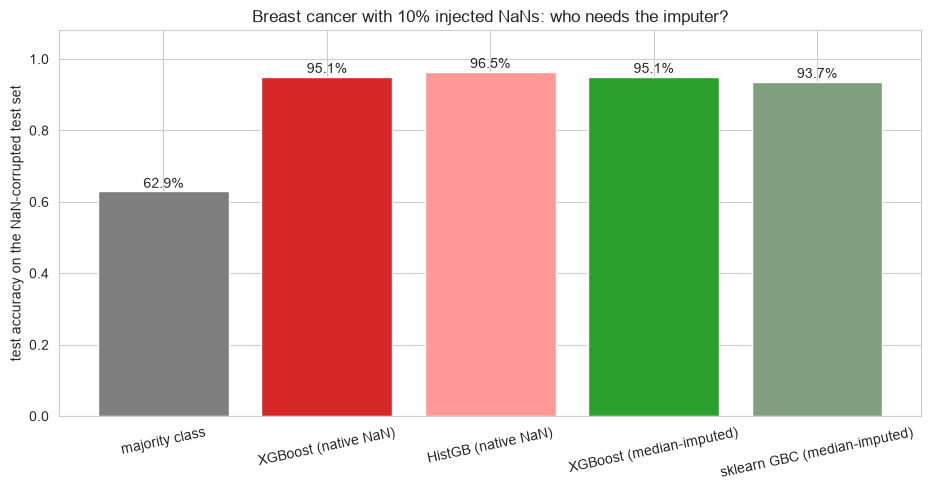


💡 XGBoost learns a default direction per feature: at each split, the missing rows
   are sent to whichever branch earns more gain, and that direction is remembered.
   Imputing first changes nothing worth having here. The engine that needs the
   imputer is the plain sklearn skeleton - the one XGBoost rebuilt from.


In [4]:
# The section 3 demo: NaN robustness - XGBoost natively, its sklearn skeleton, HistGB
bc_nan = load_breast_cancer()
Xbn_tr, Xbn_te, ybn_tr, ybn_te = train_test_split(
    bc_nan.data, bc_nan.target, test_size=0.25, stratify=bc_nan.target, random_state=42
)

# Inject 10% missingness - independently per cell, train and test
rng_nan = np.random.default_rng(0)
nan_mask_tr = rng_nan.random(Xbn_tr.shape) < 0.10
nan_mask_te = rng_nan.random(Xbn_te.shape) < 0.10
Xbn_tr_nan = Xbn_tr.copy()
Xbn_tr_nan[nan_mask_tr] = np.nan
Xbn_te_nan = Xbn_te.copy()
Xbn_te_nan[nan_mask_te] = np.nan
print(f"rows in train: {len(Xbn_tr)}, cells set to NaN: {nan_mask_tr.sum()}/{Xbn_tr.size}")

xgb_nan = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                        random_state=42).fit(Xbn_tr_nan, ybn_tr)
hist_nan = HistGradientBoostingClassifier(max_depth=3, random_state=42).fit(Xbn_tr_nan, ybn_tr)

print(f"XGBoost on NaN train data:            test acc {xgb_nan.score(Xbn_te_nan, ybn_te):.1%}"
      f"  |  clean test acc {xgb_nan.score(Xbn_te, ybn_te):.1%}")
print(f"HistGradientBoosting on NaN data:     test acc {hist_nan.score(Xbn_te_nan, ybn_te):.1%}")

try:
    GradientBoostingClassifier(n_estimators=100).fit(Xbn_tr_nan, ybn_tr)
    print("sklearn GradientBoostingClassifier:   fitted (unexpected)")
except ValueError:
    print("sklearn GradientBoostingClassifier:   ValueError - refuses NaN, imputation required")

# For the control row: standard practice (median imputation in a pipeline) recovers the
# plain sklearn engine; for XGBoost itself, imputing changes nothing worth having
xgb_imputed = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("xgb", XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                              random_state=42))]).fit(Xbn_tr_nan, ybn_tr)
gbc_imputed = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42))]).fit(Xbn_tr_nan, ybn_tr)

majority_nan = max(np.bincount(ybn_te)) / len(ybn_te)
rows_nan = [
    ("majority class", majority_nan),
    ("XGBoost (native NaN)", xgb_nan.score(Xbn_te_nan, ybn_te)),
    ("HistGB (native NaN)", hist_nan.score(Xbn_te_nan, ybn_te)),
    ("XGBoost (median-imputed)", xgb_imputed.score(Xbn_te_nan, ybn_te)),
    ("sklearn GBC (median-imputed)", gbc_imputed.score(Xbn_te_nan, ybn_te)),
]

fig, ax = plt.subplots(figsize=(9.5, 5))
labels_nan = [name_nan for name_nan, _ in rows_nan]
vals_nan = [v_nan for _, v_nan in rows_nan]
ax.bar(labels_nan, vals_nan, color=["#7f7f7f", "#d62728", "#ff9896", "#2ca02c", "#7f9f7f"])
for i_nan, v_nan in enumerate(vals_nan):
    ax.text(i_nan, v_nan + 0.01, f"{v_nan:.1%}", ha="center")
ax.set_ylim(0, 1.08)
ax.set_ylabel("test accuracy on the NaN-corrupted test set")
ax.set_title("Breast cancer with 10% injected NaNs: who needs the imputer?")
ax.tick_params(axis="x", labelrotation=12)
plt.tight_layout()
plt.show()

print("\n💡 XGBoost learns a default direction per feature: at each split, the missing rows")
print("   are sent to whichever branch earns more gain, and that direction is remembered.")
print("   Imputing first changes nothing worth having here. The engine that needs the")
print("   imputer is the plain sklearn skeleton - the one XGBoost rebuilt from.")

Key takeaways from the demo: XGBoost and HistGradientBoosting fit on the corrupted data directly and lose almost nothing; the plain sklearn skeleton refuses the same matrix flat. The default-direction learning is why "just let XGBoost see the missing values" is a legitimate production strategy — and why an imputation step still matters when *serving* data introduces NaNs the training data never had.

---

## 4. When to Use This Algorithm

### ✅ Use XGBoost When:

1. **Tabular accuracy is the priority and tuning is on the table**
   - The second-order regularized objective is the strongest practical accuracy/budget combination on structured data
2. **The data has holes or hostile geometry**
   - Native NaN routing, no scaling, robust to outliers and mixed scales — the whole tree-family advantage (notebook 03), now with the bells
3. **Medium-to-large datasets with speed/subsampling**
   - Histogram splits (`tree_method="hist"`, the default) keep split search fast as candidate counts grow; subsample/colsample give regularization levers sklearn's plain GBM lacks
4. **Production-grade engineering is required**
   - Early stopping as a constructor parameter, GPU (`device="cuda"`), serialization, monotone/interaction constraints
5. **Probability-like outputs on decision-critical tasks**
   - Log-loss boosting yields sensible probabilities, verified the same way as notebook 08 (Brier/reliability read, §10 Example 1)

### ❌ Avoid XGBoost When:

1. **Tiny datasets (< ~100 rows)**
   - The splits, the per-leaf statistics, and the regularizer all need rows; a linear model or a pruned single tree is steadier
2. **Extrapolation is required**
   - Trees clamp to the training range — a non-starter for forecasting trends
3. **A hard prediction-latency budget with deep ensembles**
   - Every prediction traverses B trees; shallow Ensembles with early stopping keep traversal cheap, but the *simplest* fit is still a linear scoring model
4. **Categorical-heavy data with high cardinality and no time to engineer**
   - CatBoost (notebook 11) treats categoricals natively; on XGBoost you encode (`enable_categorical` gets you far, but does not do frequency/target encodings for you)
5. **You need calibrated probabilities with no verification step**
   - Confident-but-wrong is the failure mode of any boosted probability; check the reliability diagram before decisions depend on `predict_proba`

### Classification vs Regression

| | Classification | Regression |
|---|---|---|
| Estimator | `XGBClassifier` | `XGBRegressor` |
| Default objective | `binary:logistic` / `multi:softprob` | `reg:squarederror` |
| $g_i$, $h_i$ | $p - y$; $p(1-p)$ (per class k, softmax) | $F - y$; $1$ |
| Default metric | `logloss` / `mlogloss` | `rmse` |
| Trees per stage | 1 (binary), K (multiclass) | 1 |
| From-scratch twin | family twin `GradientBoostingClassifierScratch` (§5) | none — library-only (§6) |

---

## 5. Implementation from Scratch (NumPy)

### Why Hands-On, When XGBoost Itself Is Compiled?

XGBoost *the library* is a compiled C++/GPU system — the repo does not (and should not) re-implement that part. What the repo does implement is the **gradient boosting skeleton** the algorithm builds on: `GradientBoostingClassifierScratch` in `src/models/ensemble_models.py`, the notebook-08 twin with its Newton leaf values.

This section uses that twin for three purposes:

1. **A guided tour of the shared skeleton** — the parts XGBoost keeps unchanged (F0, residual fitting, shrinkage, staged replay)
2. **A bit-for-bit bridge**: the twin's `_newton_leaf_values` computes exactly XGBoost's leaf weight $w^* = -G/(H+\lambda)$ **at λ = 0** — verified numerically below
3. **A hand-built λ-regularized boosting loop** (in-notebook, NumPy + the twin's stage trees), so the regularizer's effect is observable, not just called out

What is deliberately **not** hand-built here: the histogram split search (`max_bin`), the weighted-quantile candidate proposal, the sparsity-aware NaN router, and the C++/GPU execution paths. Those are XGBoost's engineering contributions; the coordinates get discussed where they matter (§6, §8) but never re-computed.

In [5]:
# Import the family twin (the gradient boosting skeleton behind XGBoost)
import sys
sys.path.append('../src')

from models.ensemble_models import GradientBoostingClassifierScratch
from models.tree_models import DecisionTreeRegressorScratch

print("✅ Imported the family twin from src/models/ensemble_models.py!")
print("\nWhat the twin provides (see notebook 08's guided tour in section 5):")
print("  • GradientBoostingClassifierScratch: stagewise additive model on log-loss /")
print("    softmax deviance, with Newton leaf values sum(g)/sum(h)")
print("  • DecisionTreeRegressorScratch: the regression tree each stage fits to residuals")
print("\nWhat notebook 09 hand-builds on top of it (XGBoost's math, in this notebook only):")
print("  • lambda-regularized leaf values  w* = -G / (H + lambda)")
print("    (the twin's _newton_leaf_values is exactly this with lambda = 0)")
print("\nWhat is NOT re-implemented (XGBoost's compiled engine handles these):")
print("  • histogram split candidates (max_bin), the weighted-quantile proposal,")
print("    sparsity-aware NaN routing, and the C++/GPU execution paths")

✅ Imported the family twin from src/models/ensemble_models.py!

What the twin provides (see notebook 08's guided tour in section 5):
  • GradientBoostingClassifierScratch: stagewise additive model on log-loss /
    softmax deviance, with Newton leaf values sum(g)/sum(h)
  • DecisionTreeRegressorScratch: the regression tree each stage fits to residuals

What notebook 09 hand-builds on top of it (XGBoost's math, in this notebook only):
  • lambda-regularized leaf values  w* = -G / (H + lambda)
    (the twin's _newton_leaf_values is exactly this with lambda = 0)

What is NOT re-implemented (XGBoost's compiled engine handles these):
  • histogram split candidates (max_bin), the weighted-quantile proposal,
    sparsity-aware NaN routing, and the C++/GPU execution paths


### The λ-Regularized Boosting Loop (Hand-Built)

One stage of XGBoost, written out with the twin's trees:

1. $F_0$: the log-odds of the positive class's base rate (XGBoost calls this quantity `base_score` and estimation in 3.x is automatic — same idea)
2. Compute $g_i = p_i - y_i$ and $h_i = p_i (1 - p_i)$ **fresh from the current $F$**
3. Fit a plain regression tree to $-g$ (the residuals $y - p$)
4. **Replace every leaf value** with $w_j^* = -G_j / (H_j + \lambda)$ — steps 3–4 over the tree's `apply` accessor, grouping training rows by leaf
5. Update $F \leftarrow F + \nu \cdot \text{tree.predict}$ — shrinkage applied exactly once

At λ = 0, step 4 collapses to the twin's Newton step — which is why the loop below is first validated to reproduce `GradientBoostingClassifierScratch(n_estimators=1)` **bit-for-bit** (both paths are fully deterministic), then swept over λ.

In [6]:
NU_HAND, DEPTH_HAND = 0.1, 3

Xm5, ym5 = make_moons(n_samples=240, noise=0.15, random_state=0)
Xm5_tr, Xm5_te, ym5_tr, ym5_te = train_test_split(Xm5, ym5, test_size=0.3, random_state=42)


def regularized_boost_loop(X_l, y_l, n_stages_l, nu_l, depth_l, lam_l):
    # XGBoost's staged skeleton, step by step, carried on the twin's stage trees.
    # Binary labels in {0, 1}; returns (f0_logit, [stage trees], nu).
    X_l = np.asarray(X_l, dtype=float)
    pos_rate = float(np.clip((y_l == 1).mean(), 1e-15, 1 - 1e-15))
    f0_l = float(np.log(pos_rate / (1 - pos_rate)))
    F_l = np.full(len(X_l), f0_l)
    trees_l = []
    for _ in range(n_stages_l):
        p_l = 1.0 / (1.0 + np.exp(-np.clip(F_l, -30.0, 30.0)))
        g_l = p_l - y_l                                  # first-order term (XGBoost sign)
        h_l = p_l * (1.0 - p_l)                          # second-order term (curvature)

        tree_l = DecisionTreeRegressorScratch(
            max_depth=depth_l, min_samples_split=2, min_samples_leaf=1
        ).fit(X_l, -g_l)                                 # the tree is fit to -g = y - p

        # XGBoost's step: overwrite every leaf with w* = -G / (H + lam)
        leaf_nodes_l = {}
        for i_l, leaf_l in enumerate(tree_l.apply(X_l)):
            leaf_nodes_l.setdefault(id(leaf_l), [leaf_l, []])[1].append(i_l)
        for _, (leaf_l, rows_l) in leaf_nodes_l.items():
            rows_a = np.asarray(rows_l)
            G_leaf_l, H_leaf_l = g_l[rows_a].sum(), h_l[rows_a].sum()
            leaf_l.value = -G_leaf_l / (H_leaf_l + lam_l)

        F_l = F_l + nu_l * tree_l.predict(X_l)
        trees_l.append(tree_l)
    return f0_l, trees_l, nu_l


# Bridge check: lambda = 0 reproduces the twin's one-stage fit bit-for-bit
f0_eq, trees_eq, nu_eq = regularized_boost_loop(Xm5_tr, ym5_tr, 1, NU_HAND, DEPTH_HAND, 0.0)
F_eq = np.full(len(Xm5_tr), f0_eq)
for tree_eq in trees_eq:
    F_eq = F_eq + nu_eq * tree_eq.predict(Xm5_tr)
p_eq = 1.0 / (1.0 + np.exp(-F_eq))

twin_one = GradientBoostingClassifierScratch(
    n_estimators=1, learning_rate=NU_HAND, max_depth=DEPTH_HAND
).fit(Xm5_tr, ym5_tr)

print(f"lambda = 0 hand-built leaf weights == twin's Newton leaves: "
      f"{np.allclose(p_eq, twin_one.predict_proba(Xm5_tr)[:, 1])}")

# ...and the two agreement mechanisms, named:
print(f"  F0 agrees:      {np.isclose(f0_eq, twin_one._f0_logit)}"
      f"  (log-odds of the positive base rate)")
print(f"  curvature use:  both engines size leaves by sum(h) - the twin stores")
print(f"                  sum(residual) / max(sum(curvature), 1e-12); that IS -G/(H + 0)")

lambda = 0 hand-built leaf weights == twin's Newton leaves: True
  F0 agrees:      True  (log-odds of the positive base rate)
  curvature use:  both engines size leaves by sum(h) - the twin stores
                  sum(residual) / max(sum(curvature), 1e-12); that IS -G/(H + 0)


 lambda  train acc  test acc  mean |F| on train
 0.0000     0.9940    0.9722             2.5903
 0.5000     0.9821    0.9722             2.3547
 2.0000     0.9643    0.9583             1.9443
10.0000     0.9345    0.9306             1.3392


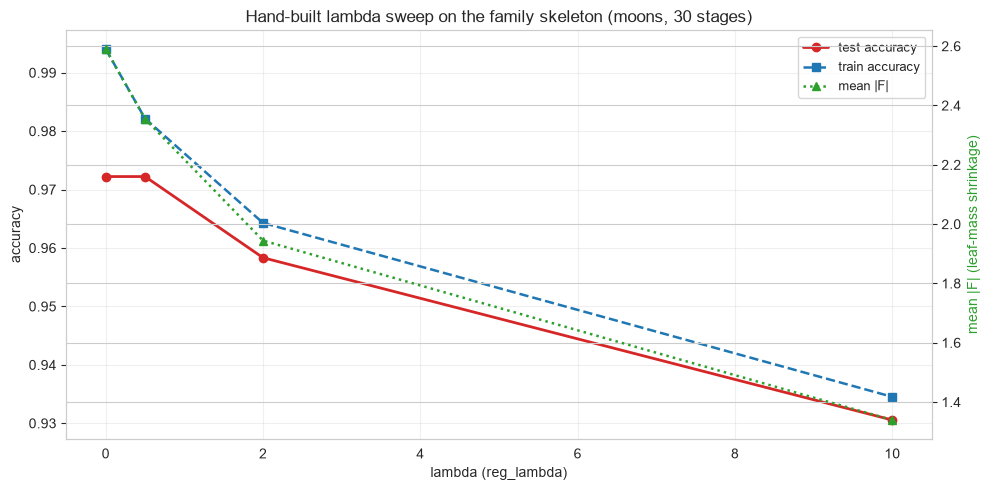


💡 lambda = 0 is the notebook-08 twin exactly. As lambda grows, the leaf values
   are taxed toward 0 (mean |F| falls) - the model must earn its mass against the
   L2 price. Small-to-moderate lambda smooths noise-driven leaves away; extreme
   lambda underfits by making almost every stage a near-no-op.


In [7]:
# The lambda sweep: same loop, only reg_lambda changes (30 stages, nu = 0.1, depth 3)
lam_sweep = [0.0, 0.5, 2.0, 10.0]
rows_lam = []
for lam_s in lam_sweep:
    f0_s, trees_s, nu_s = regularized_boost_loop(Xm5_tr, ym5_tr, 30, NU_HAND, DEPTH_HAND, lam_s)
    F_tr_s = np.full(len(Xm5_tr), f0_s)
    F_te_s = np.full(len(Xm5_te), f0_s)
    for tree_s in trees_s:
        F_tr_s = F_tr_s + nu_s * tree_s.predict(Xm5_tr)
        F_te_s = F_te_s + nu_s * tree_s.predict(Xm5_te)
    p_tr_s = 1.0 / (1.0 + np.exp(-F_tr_s))
    p_te_s = 1.0 / (1.0 + np.exp(-F_te_s))
    acc_tr_s = np.mean((p_tr_s >= 0.5).astype(int) == ym5_tr)
    acc_te_s = np.mean((p_te_s >= 0.5).astype(int) == ym5_te)
    rows_lam.append({"lambda": lam_s, "train acc": acc_tr_s, "test acc": acc_te_s,
                     "mean |F| on train": np.abs(F_tr_s).mean()})

sweep_lam = pd.DataFrame(rows_lam)
print(sweep_lam.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sweep_lam["lambda"], sweep_lam["test acc"], "o-", color="#d62728", lw=2, label="test accuracy")
ax1.plot(sweep_lam["lambda"], sweep_lam["train acc"], "s--", color="#1f77b4", lw=1.8, label="train accuracy")
ax1.set_xlabel("lambda (reg_lambda)")
ax1.set_ylabel("accuracy")
ax2 = ax1.twinx()
ax2.plot(sweep_lam["lambda"], sweep_lam["mean |F| on train"], "^:", color="#2ca02c", lw=1.8, label="mean |F|")
ax2.set_ylabel("mean |F| (leaf-mass shrinkage)", color="#2ca02c")
lines_l = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels_l = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines_l, labels_l, fontsize=9, loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.set_title("Hand-built lambda sweep on the family skeleton (moons, 30 stages)")
plt.tight_layout()
plt.show()

print("\n💡 lambda = 0 is the notebook-08 twin exactly. As lambda grows, the leaf values")
print("   are taxed toward 0 (mean |F| falls) - the model must earn its mass against the")
print("   L2 price. Small-to-moderate lambda smooths noise-driven leaves away; extreme")
print("   lambda underfits by making almost every stage a near-no-op.")

### How the Family Twin Works, and What XGBoost Adds

Read `src/models/ensemble_models.py` alongside these facts:

**1. The initial guess F0 is a base rate, both in the twin and in XGBoost (`fit`).**
The twin stores $F_0 = \log\frac{r}{1-r}$ for the positive class's base rate $r$ (clipped away from 0/1) as `_f0_logit`. XGBoost calls the same quantity `base_score` — since 3.0 it is estimated automatically from the labels instead of fixed at 0.5.

**2. $g$ and $h$ are recomputed fresh from the current $F$ at every stage (`fit`).**
The twin: `grad = y - p`, curvature `p * (1 - p)`; logs pass through a ±30 clip before `exp()` so probabilities stay inside float64 range — a numerical-saturation guard, not a modeling choice.

**3. Stage trees are plain least-squares regressors whose leaves are then replaced (`_newton_leaf_values`).**
The classmethod regroups the training rows by leaf through the tree's `apply` accessor and overwrites each leaf's value with $\sum g / \max(\sum h, 10^{-12})$ — that is precisely XGBoost's $w^* = -G / (H + \lambda)$ with λ = 0, as verified in the bridge cell above.

**4. Shrinkage is applied exactly once per stage (`fit`).**
$F \leftarrow F + \nu \, h_m$; the raw tree output is never added unscaled. `estimators_` records each stage's trees (binary: one; multiclass: one per class). $\nu$ is XGBoost's `eta`/`learning_rate`.

**5. Prediction replays the stages (`_decision` → `predict_proba`).**
$F$ is rebuilt from $F_0$ by adding $\nu \cdot h_m(x)$ over all stored stages, then a sigmoid (binary) or clipped softmax (multiclass) converts scores to probabilities.

**6. Nothing in the twin is random (`random_state` accepted, unused).**
No subsampling is implemented; the split search is deterministic. XGBoost's `subsample`, `colsample_by*`, and `sampling_method` are the stochastic extras.

**7. What XGBoost adds beyond this skeleton — the honest inventory:**

| XGBoost feature | What it does | Where it shows up here |
|---|---|---|
| $\lambda$ / $\gamma$ regularization | leaf shrinkage + the split toll | §2 (formulas) & §5 (hand-built $\lambda$) |
| `min_child_weight` | floors $\sum h_i$ per leaf — the hessian version of `min_samples_leaf` (notebook 03) | §7 sweep |
| Sparsity-aware splits | a learned default direction routes NaNs | §3 demo |
| Histogram split search (`max_bin`) | binned candidate thresholds; split cost independent of $n$ | §6, §8 (discussed, not re-implemented) |
| Weighted-quantile proposal | candidate cuts drawn by second-order-weighted quantiles | §8 (discussed) |
| Early stopping + eval histories | validation-driven stage budget | §7, §10 |
| `device="cuda"`, serialization, constraints | systems engineering | §8 reference |

---

## 6. Implementation with XGBoost

XGBoost 3.3 (the version pinned in `uv.lock`) presents one engine through two doors:

- The **sklearn estimator interface** — `XGBClassifier` / `XGBRegressor` — plugs into `cross_val_score`, `GridSearchCV`, and the rest of the sklearn ecosystem
- The **native API** — `xgb.DMatrix` + `xgb.train` — exposes the compiled engine directly: cached predictions, weights, per-sample contributions (`pred_contribs`, native SHAP values), and the early-stopping callback

Interface notes worth pinning (3.x, verified against the docs):

- `eval_metric` and `early_stopping_rounds` are **constructor parameters** of the sklearn wrapper (moved out of `fit` in 2.x); `eval_set` stays a `fit` argument
- After early stopping, `predict`/`score`/`apply` **automatically use the best iteration** — no manual range management
- `n_jobs` defaults to **every available core**; set it explicitly when wrapping in parallel sklearn tools (§7)
- `tree_method="auto"` resolves to the histogram method; the exact greedy path still exists
- `booster=gblinear` is **deprecated in 3.3.0** and scheduled for removal — do not reach for it

trees in the ensemble:    100
test accuracy:            98.6%
probability shape:        (72, 2)   (rows sum to 1: True)
feature_importances_ (gain): [0.335 0.665]


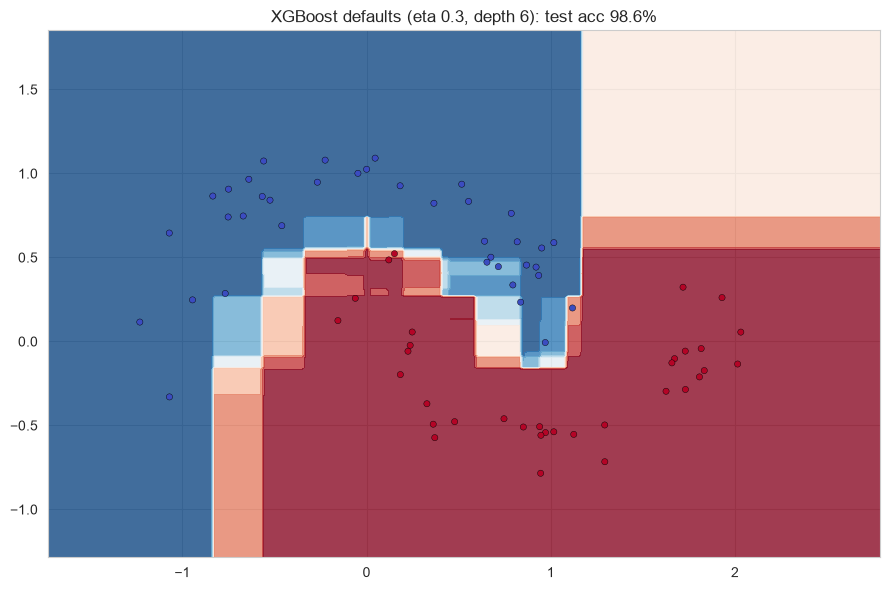


💡 The defaults are designed for large data: eta = 0.3 with depth-6 trees is
   enough capacity to memorize a few hundred rows. The tuned runs below bring eta
   down and depth in - the classic small-data job for this family.


In [8]:
# First fit: the estimator interface at XGBoost's own defaults
Xm6, ym6 = make_moons(n_samples=240, noise=0.15, random_state=0)
Xm6_tr, Xm6_te, ym6_tr, ym6_te = train_test_split(Xm6, ym6, test_size=0.3, random_state=42)

clf_xgb_first = XGBClassifier(tree_method="hist", random_state=42).fit(Xm6_tr, ym6_tr)

proba_first = clf_xgb_first.predict_proba(Xm6_te)

print(f"trees in the ensemble:    {clf_xgb_first.get_booster().num_boosted_rounds()}")
print(f"test accuracy:            {clf_xgb_first.score(Xm6_te, ym6_te):.1%}")
print(f"probability shape:        {proba_first.shape}   (rows sum to 1: {np.allclose(proba_first.sum(axis=1), 1)})")
print(f"feature_importances_ (gain): {np.round(clf_xgb_first.feature_importances_, 3)}")

fig, ax = plt.subplots(figsize=(9, 6))
pad_first = 0.5
xx_first, yy_first = np.meshgrid(
    np.linspace(Xm6[:, 0].min() - pad_first, Xm6[:, 0].max() + pad_first, 220),
    np.linspace(Xm6[:, 1].min() - pad_first, Xm6[:, 1].max() + pad_first, 220),
)
grid_first = np.c_[xx_first.ravel(), yy_first.ravel()]
field_first = clf_xgb_first.predict_proba(grid_first)[:, 1].reshape(xx_first.shape)
ax.contourf(xx_first, yy_first, field_first, levels=np.linspace(0.0, 1.0, 11), cmap="RdBu_r", alpha=0.8)
ax.scatter(Xm6_te[:, 0], Xm6_te[:, 1], c=ym6_te, cmap="coolwarm", s=20, edgecolors="k", linewidths=0.3)
ax.set_title(f"XGBoost defaults (eta 0.3, depth 6): test acc {clf_xgb_first.score(Xm6_te, ym6_te):.1%}")
plt.tight_layout()
plt.show()

print("\n💡 The defaults are designed for large data: eta = 0.3 with depth-6 trees is")
print("   enough capacity to memorize a few hundred rows. The tuned runs below bring eta")
print("   down and depth in - the classic small-data job for this family.")

### Dual Engine: the Family Twin vs XGBoost on the Same Data

Both engines get the identical moons split, 50 stages, $\nu = 0.1$, depth-3 trees. Two XGBoost runs bracket the regularizer: **λ = 0** (the strongest possible match with the twin's mathematics) and **λ = 1** (XGBoost's shipping default). They should land close but not identical — and the reasons are the same ones notebook 08 listed, plus the histogram:

- **Split candidates**: XGBoost's `hist` method proposes thresholds from feature-value bins (up to `max_bin`); the twin and sklearn scan data values. Different candidate grids → different split thresholds where the data is dense
- **The regularizer acts during the fit, not after it**: λ enters the leaf formula *and* the split gain, so λ = 1's tree shapes, not values, subtly change
- **Shared Newton leaf mathematics**: with λ = 0 the leaf-formula pieces agree exactly (§5's bridge check) — the shapes remain comparable even where individual split choices wobble

                                     twin  xgb (lam=0)  xgb (lam=1)
test accuracy                       95.8%       100.0%        98.6%
mean |p - p_twin|                               0.0480       0.0543
label agreement                                  95.8%        94.4%
fit time (s)                                      0.02         0.03


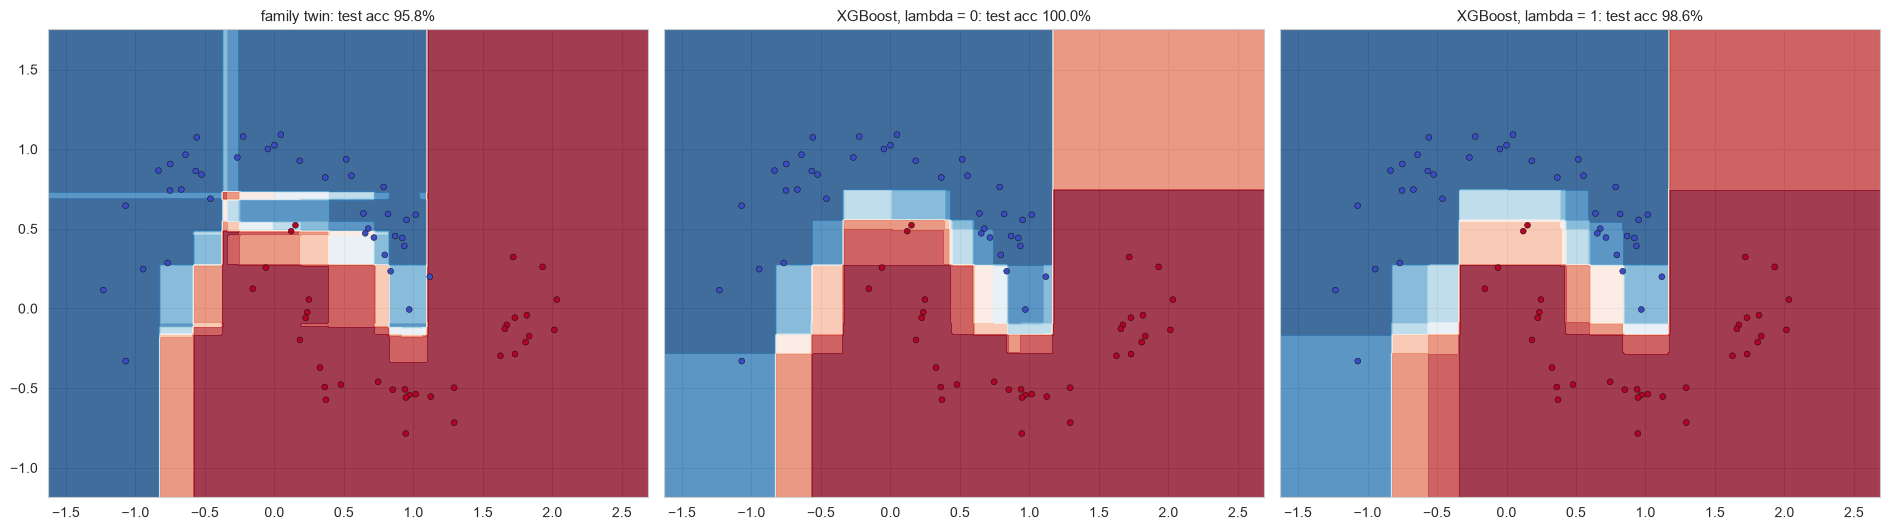


💡 Same skeleton, same leaf math, slightly different split candidates -> nearly
   the same boundary. The λ = 0 run brackets the exact-skeleton match; the λ = 1
   run shows XGBoost's shipping default pulls the field subtly tighter.


In [9]:
gb_twin_de = GradientBoostingClassifierScratch(
    n_estimators=50, learning_rate=0.1, max_depth=3
).fit(Xm6_tr, ym6_tr)

t0 = time.perf_counter()
xgb_de = XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=3,
                       reg_lambda=0.0, gamma=0.0, tree_method="hist",
                       random_state=0).fit(Xm6_tr, ym6_tr)
t_xgb_l0 = time.perf_counter() - t0

t0 = time.perf_counter()
xgb_de_l1 = XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=3,
                          reg_lambda=1.0, gamma=0.0, tree_method="hist",
                          random_state=0).fit(Xm6_tr, ym6_tr)
t_xgb_l1 = time.perf_counter() - t0

proba_twin_de = gb_twin_de.predict_proba(Xm6_te)[:, 1]
proba_l0_de = xgb_de.predict_proba(Xm6_te)[:, 1]
proba_l1_de = xgb_de_l1.predict_proba(Xm6_te)[:, 1]

print(f"{'':30s} {'twin':>10s} {'xgb (lam=0)':>12s} {'xgb (lam=1)':>12s}")
print(f"{'test accuracy':30s} {gb_twin_de.score(Xm6_te, ym6_te):>10.1%} "
      f"{xgb_de.score(Xm6_te, ym6_te):>12.1%} {xgb_de_l1.score(Xm6_te, ym6_te):>12.1%}")
print(f"{'mean |p - p_twin|':30s} {'':>10s} "
      f"{np.abs(proba_l0_de - proba_twin_de).mean():>12.4f} "
      f"{np.abs(proba_l1_de - proba_twin_de).mean():>12.4f}")
print(f"{'label agreement':30s} {'':>10s} "
      f"{np.mean((proba_l0_de >= 0.5) == (proba_twin_de >= 0.5)):>12.1%} "
      f"{np.mean((proba_l1_de >= 0.5) == (proba_twin_de >= 0.5)):>12.1%}")
print(f"{'fit time (s)':30s} {'':>10s} {t_xgb_l0:>12.2f} {t_xgb_l1:>12.2f}")

pad_de = 0.4
xx_de, yy_de = np.meshgrid(
    np.linspace(Xm6[:, 0].min() - pad_de, Xm6[:, 0].max() + pad_de, 250),
    np.linspace(Xm6[:, 1].min() - pad_de, Xm6[:, 1].max() + pad_de, 250),
)
grid_de = np.c_[xx_de.ravel(), yy_de.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), sharey=True)
for ax, (name_de, est_de) in zip(axes, [("family twin", gb_twin_de),
                                        ("XGBoost, lambda = 0", xgb_de),
                                        ("XGBoost, lambda = 1", xgb_de_l1)]):
    Z_de = est_de.predict_proba(grid_de)[:, 1].reshape(xx_de.shape)
    ax.contourf(xx_de, yy_de, Z_de, levels=np.linspace(0.0, 1.0, 11), cmap="RdBu_r", alpha=0.8)
    ax.scatter(Xm6_te[:, 0], Xm6_te[:, 1], c=ym6_te, cmap="coolwarm", s=18,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"{name_de}: test acc {est_de.score(Xm6_te, ym6_te):.1%}", fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Same skeleton, same leaf math, slightly different split candidates -> nearly")
print("   the same boundary. The λ = 0 run brackets the exact-skeleton match; the λ = 1")
print("   run shows XGBoost's shipping default pulls the field subtly tighter.")

### The Four Feature Importances

Impurity importances (notebook 04) generalize but split differently in XGBoost — the four types are computed from the trees' stored statistics:

| `importance_type` | Meaning | Bias to remember |
|---|---|---|
| `gain` | mean **objective improvement** per split using this feature | the default for the estimator interface's `feature_importances_` |
| `total_gain` | `gain` × number of splits | same ranking as `gain` when split counts are similar |
| `cover` | mean $\sum h_i$ covered per split (the leaf-size mass from §2) | hessian-weighted influence |
| `weight` | **number of times** the feature is split on | high-frequency, low-impact features can top this list |

The native API's `Booster.get_score(importance_type=...)` defaults to `weight` — so the wrapper and the native path disagree *by default*. Do not mix them in the same report.

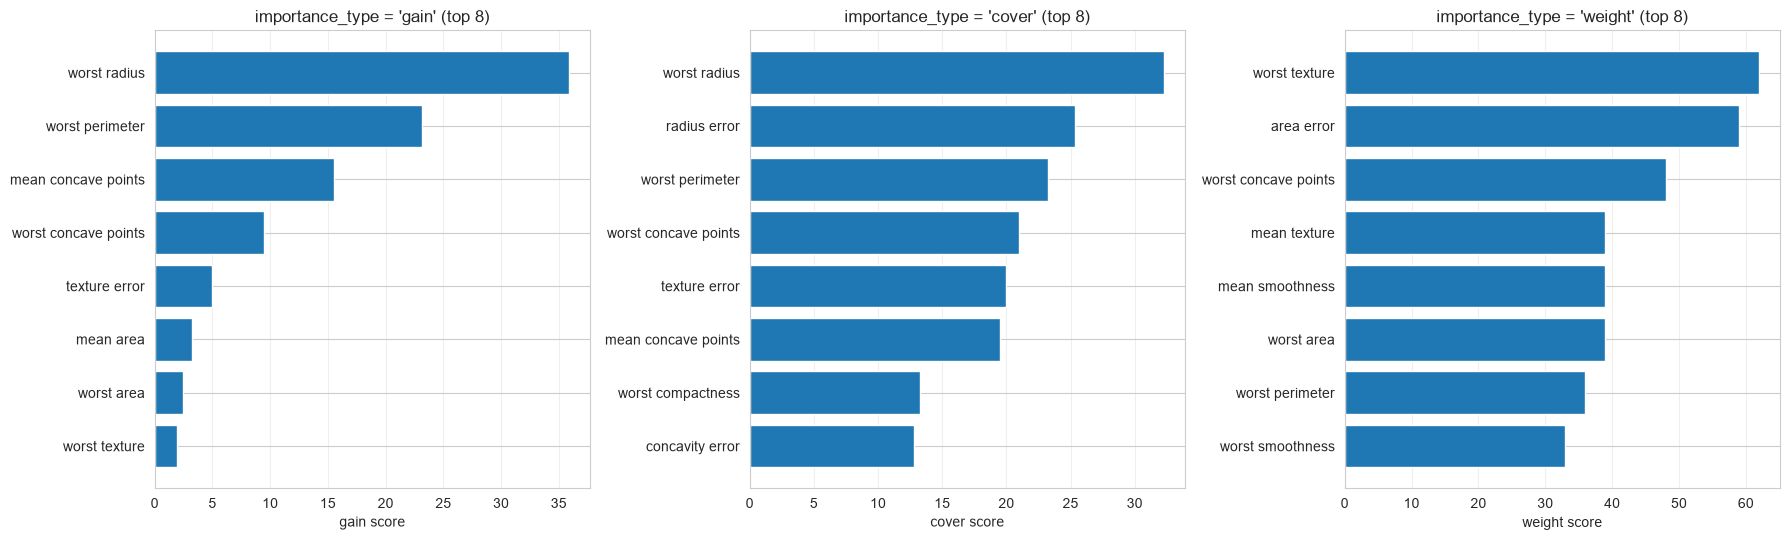

top-3 by gain:   ['worst radius', 'worst perimeter', 'mean concave points']
top-3 by weight: ['worst texture', 'area error', 'worst concave points']

gain-based wrapper attribute (feature_importances_) agrees with native 'gain': True  (normalized to sum 1)

💡 'gain' ranks by objective improvement per split; 'weight' ranks by how OFTEN a
   feature is split on - two very different questions. The heaviest breast-cancer
   signal rides on a handful of high-gain features even when they are split less
   often than lower-gain workhorses.


In [10]:
# Reuse the section 3 clean breast-cancer split (now with feature names)
Xbn_tr_df = pd.DataFrame(Xbn_tr, columns=bc_nan.feature_names)
Xbn_te_df = pd.DataFrame(Xbn_te, columns=bc_nan.feature_names)

clf_xgb_bc = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                           random_state=42).fit(Xbn_tr_df, ybn_tr)
booster_bc = clf_xgb_bc.get_booster()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
imp_maps = {}
for ax_imp, imp_type_bc in zip(axes, ["gain", "cover", "weight"]):
    scores_bc = booster_bc.get_score(importance_type=imp_type_bc)
    imp_maps[imp_type_bc] = pd.Series(scores_bc).sort_values(ascending=False)
    top_bc = imp_maps[imp_type_bc].head(8)
    ax_imp.barh(top_bc.index[::-1], top_bc.values[::-1], color="#1f77b4")
    ax_imp.set_xlabel(f"{imp_type_bc} score")
    ax_imp.set_title(f"importance_type = '{imp_type_bc}' (top 8)")
    ax_imp.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

top3_gain = list(imp_maps["gain"].head(3).index)
top3_weight = list(imp_maps["weight"].head(3).index)
print(f"top-3 by gain:   {top3_gain}")
print(f"top-3 by weight: {top3_weight}")
print(f"\ngain-based wrapper attribute (feature_importances_) agrees with native 'gain': "
      f"{np.allclose(clf_xgb_bc.feature_importances_.sum(), 1.0)}  (normalized to sum 1)")
print("\n💡 'gain' ranks by objective improvement per split; 'weight' ranks by how OFTEN a")
print("   feature is split on - two very different questions. The heaviest breast-cancer")
print("   signal rides on a handful of high-gain features even when they are split less")
print("   often than lower-gain workhorses.")

### Regression with XGBoost: XGBRegressor

The same staged machinery under `objective="reg:squarederror"`. For squared error the loss terms are the simplest possible pair: $g_i = F - y$ (the literal residual, with the opposite sign to notebook 08's $y - F$) and $h_i = 1$ — so every leaf value is the (λ-smoothed) **mean residual** of its leaf. The initial guess `base_score` is estimated from the labels, and the default metric is `rmse`.

Depth is again the per-stage complexity knob: stumps express less per stage and lean on more stages.

*(Scikit-learn only in the scratch sense: the family twin is classifier-first — the interesting second-order mechanics live in the classification losses; the squared-error leaf math is the λ-sweep of §5 with $h = 1$.)*

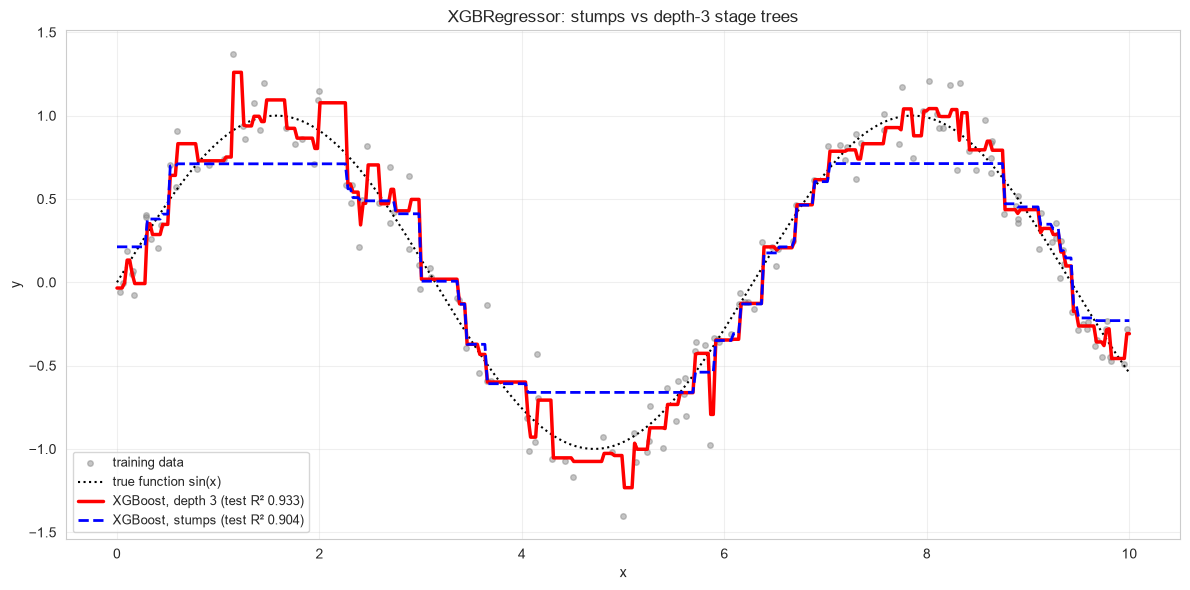

depth 3: train R² 0.9880 | test R² 0.9329 | test RMSE 0.1842
depth 1: train R² 0.8969 | test R² 0.9038 | test RMSE 0.2206

💡 Same story as notebook 08's regressor, told through XGBoost: stumps buy
   smoothness with more stages; depth is the bias/variance knob *per stage*.


In [11]:
rng_r = np.random.default_rng(0)
X_r9 = np.sort(rng_r.uniform(0.0, 10.0, 200)).reshape(-1, 1)
y_r9 = np.sin(X_r9).ravel() + rng_r.normal(0.0, 0.15, 200)
Xr9_tr, Xr9_te, yr9_tr, yr9_te = train_test_split(X_r9, y_r9, test_size=0.25, random_state=42)

reg_xgb_d3 = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                          random_state=0).fit(Xr9_tr, yr9_tr)
reg_xgb_d1 = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=1,
                          random_state=0).fit(Xr9_tr, yr9_tr)

grid_r = np.linspace(0.0, 10.0, 400).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(Xr9_tr[:, 0], yr9_tr, s=16, alpha=0.45, color="gray", label="training data")
ax.plot(grid_r, np.sin(grid_r), "k:", lw=1.5, label="true function sin(x)")
ax.plot(grid_r, reg_xgb_d3.predict(grid_r), "r-", lw=2.5,
        label=f"XGBoost, depth 3 (test R² {r2_score(yr9_te, reg_xgb_d3.predict(Xr9_te)):.3f})")
ax.plot(grid_r, reg_xgb_d1.predict(grid_r), "b--", lw=2,
        label=f"XGBoost, stumps (test R² {r2_score(yr9_te, reg_xgb_d1.predict(Xr9_te)):.3f})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("XGBRegressor: stumps vs depth-3 stage trees")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"depth 3: train R² {reg_xgb_d3.score(Xr9_tr, yr9_tr):.4f} | "
      f"test R² {r2_score(yr9_te, reg_xgb_d3.predict(Xr9_te)):.4f} | "
      f"test RMSE {np.sqrt(mean_squared_error(yr9_te, reg_xgb_d3.predict(Xr9_te))):.4f}")
print(f"depth 1: train R² {reg_xgb_d1.score(Xr9_tr, yr9_tr):.4f} | "
      f"test R² {r2_score(yr9_te, reg_xgb_d1.predict(Xr9_te)):.4f} | "
      f"test RMSE {np.sqrt(mean_squared_error(yr9_te, reg_xgb_d1.predict(Xr9_te))):.4f}")
print("\n💡 Same story as notebook 08's regressor, told through XGBoost: stumps buy")
print("   smoothness with more stages; depth is the bias/variance knob *per stage*.")

### The Native API: `DMatrix` and `xgb.train`

The estimator interface is the tool for notebook-style work. The native API is what production XGBoost is written against, and it earns its place by handling what the wrapper does not:

- **`xgb.DMatrix`**: XGBoost's internal data container — quantized, sparse-aware, supports row weights and per-feature `feature_weights`, and can be cached for repeated predictions
- **`xgb.train(params, dtrain, num_boost_round=...)`**: explicit control over boosting rounds; the early stopping live as **callbacks** (`xgb.callback.EarlyStopping`) in 3.x
- **`pred_contribs`**: per-sample feature contributions (native SHAP values) from `Booster.predict(..., pred_contribs=True)` — no separate `shap` package required
- `Booster.predict(..., iteration_range=...)` pins the tree range read back; `save_model` / `load_model` are format-stable JSON

The demo below repeats the wrapper's mood on the same moons data: `xgb.train` with a validation watch list and the early-stopping callback.

In [12]:
dtrain_native = xgb.DMatrix(Xm6_tr, label=ym6_tr)
dvalid_native = xgb.DMatrix(Xm6_te, label=ym6_te)

params_native = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "learning_rate": 0.1,
    "max_depth": 3,
    "reg_lambda": 1.0,
}
es_native = xgb.callback.EarlyStopping(rounds=15, save_best=True,
                                       data_name="valid", metric_name="logloss")

t0 = time.perf_counter()
booster_native = xgb.train(
    params_native, dtrain_native,
    num_boost_round=300,
    evals=[(dtrain_native, "train"), (dvalid_native, "valid")],
    callbacks=[es_native], verbose_eval=False,
)
t_native = time.perf_counter() - t0

proba_native = booster_native.predict(
    dvalid_native, iteration_range=(0, booster_native.best_iteration + 1)
)
print(f"stopped with best_iteration = {booster_native.best_iteration} of 300 requested rounds")
print(f"native-API test accuracy: {np.mean(proba_native.round() == ym6_te):.1%}  (best-round predict)")

# Native SHAP-style feature contributions - no extra package needed
contribs_native = booster_native.predict(dvalid_native, pred_contribs=True)
i_row = int(np.argmax(np.abs(contribs_native[:, :-1]).sum(axis=1)))
print(f"pred_contribs matrix: {contribs_native.shape}  (last column is the bias term)")
print(f"most-influenced test row #{i_row}: dominant feature index "
      f"{int(np.argmax(np.abs(contribs_native[i_row, :-1])))}, bias {contribs_native[i_row, -1]:+.3f}")

print("\n💡 The native API is the same engine with the switches exposed. In production,")
print("   DMatrix construction costs pay for themselves through cached predictions,")
print("   and pred_contribs turns 'why did the model say yes?' into one predict call.")

stopped with best_iteration = 195 of 300 requested rounds
native-API test accuracy: 100.0%  (best-round predict)
pred_contribs matrix: (72, 3)  (last column is the bias term)
most-influenced test row #13: dominant feature index 1, bias +0.034

💡 The native API is the same engine with the switches exposed. In production,
   DMatrix construction costs pay for themselves through cached predictions,
   and pred_contribs turns 'why did the model say yes?' into one predict call.


---

## 7. Hyperparameter Tuning

The levers that matter, in the order they are usually tuned:

1. **`learning_rate` (η) × `n_estimators`** — one trade (notebook 08). Search η on a **log grid**; small η needs many stages
2. **`max_depth` and `min_child_weight`** — what each tree can express, and the leaf-size floor on $\sum H$
3. **`subsample` / `colsample_bytree`** — stochastic damping, the variance reducers
4. **`reg_lambda` / `reg_alpha` / `gamma`** — the regularizer 90210: leaf shrinkage, leaf sparsity, and the split toll

Four rules govern the sweeps:

1. η, γ, λ act **multiplicatively** — log-scale grids, never linear
2. **η and stage count together**; a small η is only slow, a large η can be wrong
3. Tune with **cross-validation on training data only**; the test set reports once
4. `n_jobs`: XGBoost defaults to **all cores**; set XGBoost's `n_jobs=1` inside a parallel sklearn sweep (`GridSearchCV(n_jobs=-1)`) to avoid thread thrashing

The tuning data below is a noisier moons set (480 rows, noise 0.25) — same recipe as notebook 08, so the two hyperparameter stories can be compared stage for stage.

In [13]:
# The tuning split used throughout section 7
Xt7, yt7 = make_moons(n_samples=480, noise=0.25, random_state=3)
Xt7_tr, Xt7_te, yt7_tr, yt7_te = train_test_split(Xt7, yt7, test_size=0.3,
                                                  stratify=yt7, random_state=42)
print(f"tuning data: {Xt7_tr.shape[0]} train rows / {Xt7_te.shape[0]} test rows, noise 0.25")

tuning data: 336 train rows / 144 test rows, noise 0.25


### The η × n_estimators Trade-off

XGBoost has no staged-prediction generator (its trees are grown in C++, not Python), so the sweep is refits across a stage grid - the same protocol, one implementation deeper than notebook 08's `staged_predict_proba`. Hold `max_depth = 3` and the default λ = 1.

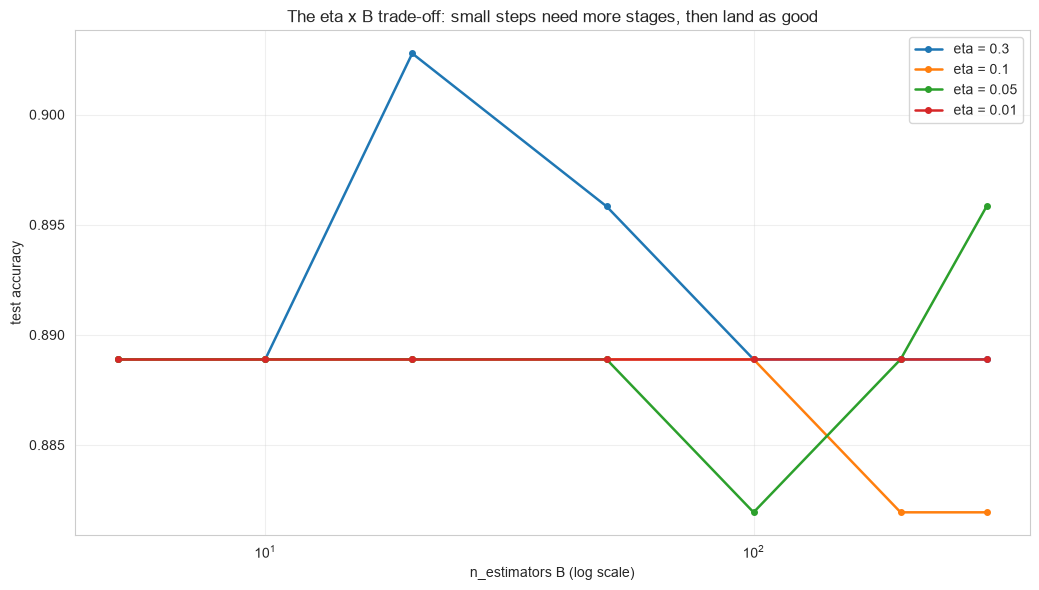

   eta | best B | best test acc
  0.30 |     20 |         90.3%
  0.10 |      5 |         88.9%
  0.05 |    300 |         89.6%
  0.01 |      5 |         88.9%

💡 eta = 0.3 peaks early and wobbles afterwards - big steps, big variance.
   eta = 0.01 needs 100+ stages but its curve keeps rising gently. Same lesson
   as notebook 08: pick eta by the stage budget you can afford, then tune B.


In [14]:
B_sweep = [5, 10, 20, 50, 100, 200, 300]
eta_sweep = [0.3, 0.1, 0.05, 0.01]
acc_by_eta = {}
for eta_v in eta_sweep:
    test_curve = []
    for B_v in B_sweep:
        m_eta = XGBClassifier(n_estimators=B_v, learning_rate=eta_v, max_depth=3,
                              random_state=0).fit(Xt7_tr, yt7_tr)
        test_curve.append(accuracy_score(yt7_te, m_eta.predict(Xt7_te)))
    acc_by_eta[eta_v] = np.array(test_curve)

fig, ax = plt.subplots(figsize=(10.5, 6))
for eta_v in eta_sweep:
    ax.plot(B_sweep, acc_by_eta[eta_v], marker="o", ms=4, lw=1.8, label=f"eta = {eta_v}")
ax.set_xscale("log")
ax.set_xlabel("n_estimators B (log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("The eta x B trade-off: small steps need more stages, then land as good")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'eta':>6s} | {'best B':>6s} | {'best test acc':>13s}")
for eta_v in eta_sweep:
    best_i = int(acc_by_eta[eta_v].argmax())
    print(f"{eta_v:>6.2f} | {B_sweep[best_i]:>6d} | {acc_by_eta[eta_v][best_i]:>13.1%}")
print("\n💡 eta = 0.3 peaks early and wobbles afterwards - big steps, big variance.")
print("   eta = 0.01 needs 100+ stages but its curve keeps rising gently. Same lesson")
print("   as notebook 08: pick eta by the stage budget you can afford, then tune B.")

### Depth and min_child_weight

Depth still sets what each stage can express, but XGBoost's **shipping default is 6** — designed for large data, too deep for a few hundred rows. `min_child_weight` is the second-order take on leaf regularization: a candidate child with $\sum h_i$ below the threshold is not split at all. For log-loss, $\sum h_i$ is small exactly where the model is near-certain, so raising it prunes the confident periphery first.

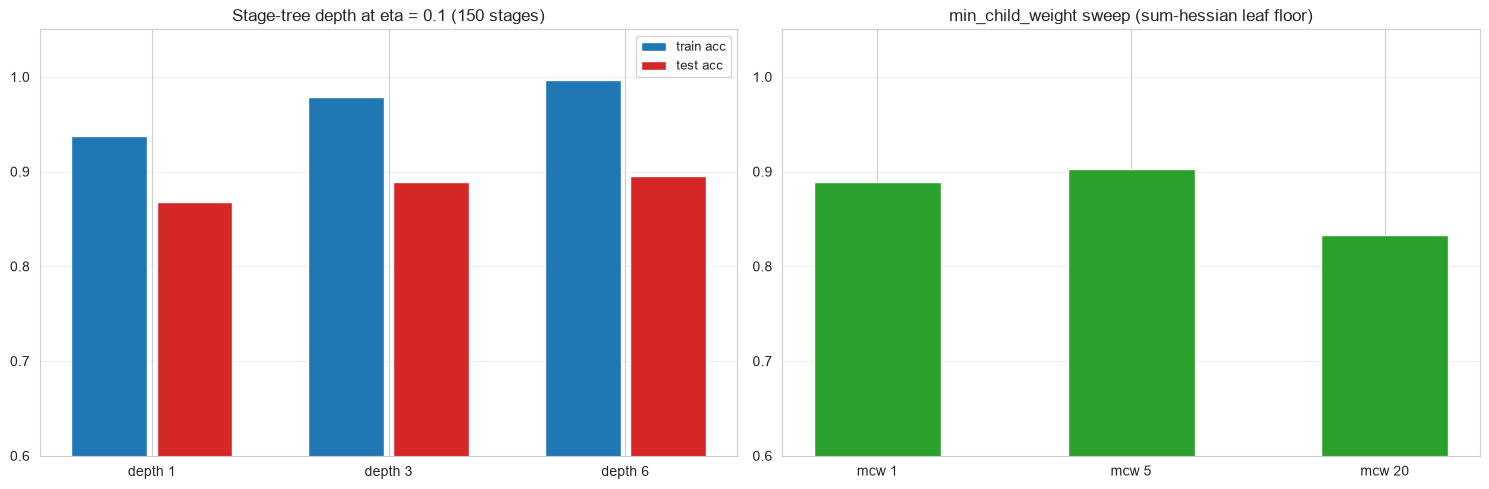

 max_depth  train acc  test acc
         1     0.9375    0.8681
         3     0.9792    0.8889
         6     0.9970    0.8958
 min_child_weight  train acc  test acc
                1     0.9792    0.8889
                5     0.9554    0.9028
               20     0.8393    0.8333

💡 Depth 6 hits train 1.0 on this small set - the shipping default is a large-data
   default. Depth 1-3 keep the train-test gap sane. min_child_weight smooths the
   confident periphery: its leaves carry small hessian sums, so raising the floor
   removes precisely the overconfident micro-leaves (the hessian view of
   notebook 03's min_samples_leaf).


In [15]:
depth_sweep = [1, 3, 6]
mcw_sweep = [1, 5, 20]

rows_depth = []
for depth_v in depth_sweep:
    m_d = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=depth_v,
                        random_state=0).fit(Xt7_tr, yt7_tr)
    rows_depth.append({"max_depth": depth_v, "train acc": m_d.score(Xt7_tr, yt7_tr),
                       "test acc": m_d.score(Xt7_te, yt7_te)})

rows_mcw = []
for mcw_v in mcw_sweep:
    m_w = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=3,
                        min_child_weight=mcw_v, random_state=0).fit(Xt7_tr, yt7_tr)
    rows_mcw.append({"min_child_weight": mcw_v, "train acc": m_w.score(Xt7_tr, yt7_tr),
                     "test acc": m_w.score(Xt7_te, yt7_te)})

df_depth = pd.DataFrame(rows_depth)
df_mcw = pd.DataFrame(rows_mcw)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x_pos_d = np.arange(len(df_depth))
axes[0].bar(x_pos_d - 0.18, df_depth["train acc"], width=0.32, color="#1f77b4", label="train acc")
axes[0].bar(x_pos_d + 0.18, df_depth["test acc"], width=0.32, color="#d62728", label="test acc")
axes[0].set_xticks(x_pos_d, [f"depth {d}" for d in df_depth["max_depth"]])
axes[0].set_ylim(0.6, 1.05)
axes[0].set_title("Stage-tree depth at eta = 0.1 (150 stages)")
axes[0].legend(fontsize=9)
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar([f"mcw {m}" for m in df_mcw["min_child_weight"]], df_mcw["test acc"],
            color="#2ca02c", width=0.5)
axes[1].set_ylim(0.6, 1.05)
axes[1].set_title("min_child_weight sweep (sum-hessian leaf floor)")
axes[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(df_depth.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(df_mcw.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n💡 Depth 6 hits train 1.0 on this small set - the shipping default is a large-data")
print("   default. Depth 1-3 keep the train-test gap sane. min_child_weight smooths the")
print("   confident periphery: its leaves carry small hessian sums, so raising the floor")
print("   removes precisely the overconfident micro-leaves (the hessian view of")
print("   notebook 03's min_samples_leaf).")

### Subsampling and the Regularizer Pair (λ, α, γ)

`subsample` rates the rows by stochasticity; `colsample_bytree` rates the features. Both add variance reduction (and both are sequential stages, unlike the forest's parallel adds), then `reg_lambda`/`reg_alpha`/`gamma` shape leaves and splits deterministically. Two compact sweeps make the interplay legible.

In [16]:
# subsample x colsample_bytree under 3-fold stratified CV
# (XGBoost n_jobs=1 inside a parallel sklearn sweep - the docs' anti-thrashing advice)
grid_sub = GridSearchCV(
    XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=3,
                  n_jobs=1, random_state=0),
    {"subsample": [1.0, 0.8, 0.6], "colsample_bytree": [1.0, 0.7, 0.5]},
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    n_jobs=-1,
)
grid_sub.fit(Xt7_tr, yt7_tr)

pivot_sub = pd.DataFrame(grid_sub.cv_results_).pivot_table(
    values="mean_test_score", index="param_subsample", columns="param_colsample_bytree")
print(pivot_sub.round(4).to_string())
print(f"\nbest: {grid_sub.best_params_}  (CV acc {grid_sub.best_score_:.4f}; "
      f"test acc {grid_sub.score(Xt7_te, yt7_te):.4f})")
print("\n💡 Subsampling trades a little signal for a lot of variance reduction: each stage")
print("   must generalize what it fitted on a view of the data. With only 30 features the")
print("   column knob moves less than the row knob - watch the axes separately.")

param_colsample_bytree     0.5     0.7     1.0
param_subsample                               
0.6                     0.9226  0.9226  0.9315
0.8                     0.9315  0.9315  0.9256
1.0                     0.9315  0.9315  0.9315

best: {'colsample_bytree': 1.0, 'subsample': 1.0}  (CV acc 0.9315; test acc 0.8889)

💡 Subsampling trades a little signal for a lot of variance reduction: each stage
   must generalize what it fitted on a view of the data. With only 30 features the
   column knob moves less than the row knob - watch the axes separately.


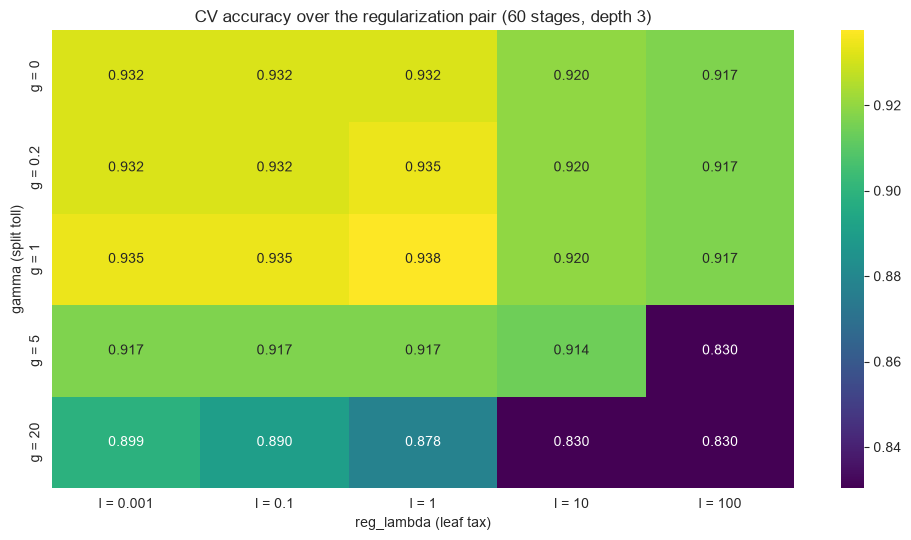

best cell: gamma = 1, lambda = 1  (CV acc 0.9375)

💡 The two regularizers act at different places in one formula - gamma inside the
   split decision, lambda inside the leaf value - so they are not redundant. The
   lambda = 100 column underfits at only 60 stages: shorter budgets sharpen the
   penalty of over-regularizing.


In [17]:
# gamma x reg_lambda grid at fixed depth 3 - the split toll vs the leaf tax
gamma_grid = [0.0, 0.2, 1.0, 5.0, 20.0]
lam_grid = [0.001, 0.1, 1.0, 10.0, 100.0]
cv_gl = StratifiedKFold(3, shuffle=True, random_state=42)
mat_gl = np.zeros((len(gamma_grid), len(lam_grid)))
for i_g, g_v in enumerate(gamma_grid):
    for j_l, lam_v in enumerate(lam_grid):
        m_gl = XGBClassifier(n_estimators=60, learning_rate=0.1, max_depth=3,
                             gamma=g_v, reg_lambda=lam_v, n_jobs=1, random_state=0)
        mat_gl[i_g, j_l] = cross_val_score(m_gl, Xt7_tr, yt7_tr, cv=cv_gl,
                                           scoring="accuracy").mean()

plot_gl = pd.DataFrame(mat_gl, index=gamma_grid, columns=lam_grid)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(plot_gl, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            yticklabels=[f"g = {g:g}" for g in gamma_grid],
            xticklabels=[f"l = {l:g}" for l in lam_grid])
ax.set_xlabel("reg_lambda (leaf tax)")
ax.set_ylabel("gamma (split toll)")
ax.set_title("CV accuracy over the regularization pair (60 stages, depth 3)")
plt.tight_layout()
plt.show()

best_cell = plot_gl.stack().idxmax()
print(f"best cell: gamma = {best_cell[0]:g}, lambda = {best_cell[1]:g}"
      f"  (CV acc {plot_gl.stack().max():.4f})")
print("\n💡 The two regularizers act at different places in one formula - gamma inside the")
print("   split decision, lambda inside the leaf value - so they are not redundant. The")
print("   lambda = 100 column underfits at only 60 stages: shorter budgets sharpen the")
print("   penalty of over-regularizing.")

### Early Stopping: A Stage Budget, Not a Target

The estimator interface carries `early_stopping_rounds` in the **constructor**; the fit receives `eval_set`. Training halts when the held-out metric stops improving; `best_iteration` marks the kept model, and predict/score automatically read from it. The docs' recommendation for the CV setting: cross-validate to choose hyperparameters, then retrain the final model **on the full training data with early stopping** — ES inside CV changes the model's tree count per fold and muddies comparisons.

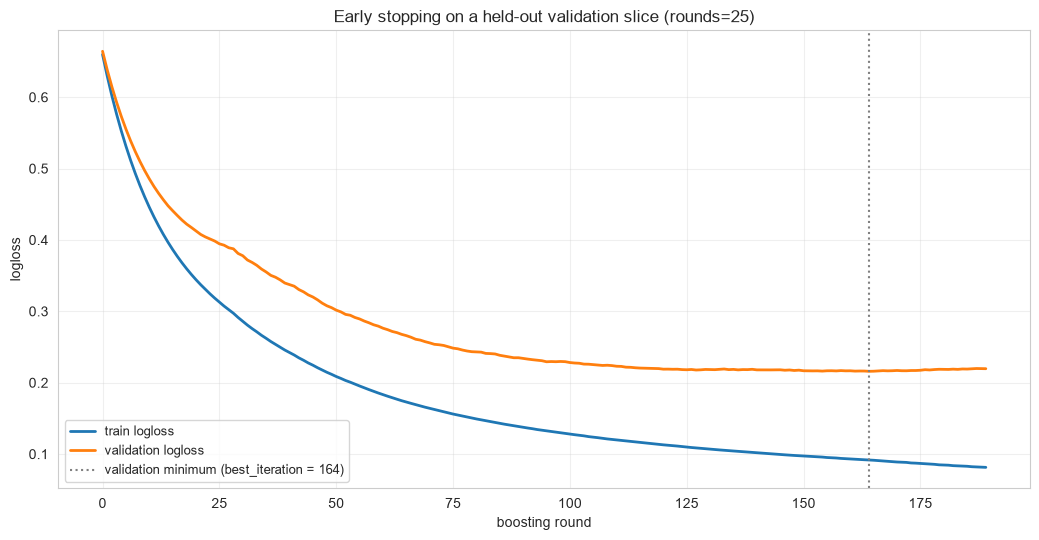

requested 600 boosts; early stopping saved best_iteration = 164  (the wrapper's predict/score auto-use rounds [0, 165))
validation logloss at the minimum: 0.2159
test accuracy (predict auto-uses the best round): 88.9%

💡 The curves tell the whole story: train logloss keeps sinking, the validation
   curve flattens then turns. Early stopping is 'the peak of that curve' automated
   - n_estimators is a budget, never a target.


In [18]:
# Validation carved out of the TRAINING portion - the test set stays sealed
Xv7_tr, Xv7_val, yv7_tr, yv7_val = train_test_split(Xt7_tr, yt7_tr, test_size=0.2,
                                                    stratify=yt7_tr, random_state=42)

clf_es = XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=3,
                       eval_metric="logloss", early_stopping_rounds=25,
                       random_state=0)
clf_es.fit(Xv7_tr, yv7_tr,
           eval_set=[(Xv7_tr, yv7_tr), (Xv7_val, yv7_val)], verbose=False)

history_es = clf_es.evals_result()

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.plot(history_es["validation_0"]["logloss"], lw=2, label="train logloss")
ax.plot(history_es["validation_1"]["logloss"], lw=2, label="validation logloss")
ax.axvline(int(np.argmin(history_es["validation_1"]["logloss"])), color="gray",
           ls=":", lw=1.5, label=f"validation minimum (best_iteration = {clf_es.best_iteration})")
ax.set_xlabel("boosting round")
ax.set_ylabel("logloss")
ax.set_title("Early stopping on a held-out validation slice (rounds=25)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"requested 600 boosts; early stopping saved best_iteration = {clf_es.best_iteration}"
      f"  (the wrapper's predict/score auto-use rounds [0, {clf_es.best_iteration + 1}))")
print(f"validation logloss at the minimum: {min(history_es['validation_1']['logloss']):.4f}")
print(f"test accuracy (predict auto-uses the best round): {clf_es.score(Xt7_te, yt7_te):.1%}")
print("\n💡 The curves tell the whole story: train logloss keeps sinking, the validation")
print("   curve flattens then turns. Early stopping is 'the peak of that curve' automated")
print("   - n_estimators is a budget, never a target.")

---

## 8. Complete Hyperparameter Reference

### XGBClassifier Parameters (xgboost 3.3.0)

Aliased parameters appear in two spellings: `eta` ↔ `learning_rate`, `lambda` ↔ `reg_lambda`, `alpha` ↔ `reg_alpha`, `gamma` ↔ `min_split_loss`. The estimator interface accepts either; `get_params()` reports the sklearn-style names. Defaults below are XGBoost's own (the wrapper passes them through), verified against the parameter reference for the pinned version.

#### `learning_rate` (float, default=0.3, alias: `eta`) **[THE HYPERPARAMETER]**
- **Description**: step-size shrinkage ν on every stage's tree contribution
- **Effect**: small η → decorrelated small corrections that accumulate smoothly; large η → big steps that overshoot and wobble (§7 sweep)
- **Tuning strategy**: fix at 0.05–0.1 for small-to-medium data, tune `n_estimators` to the plateau; XGBoost's 0.3 default targets large data
- **Example**: `XGBClassifier(learning_rate=0.05, n_estimators=500, early_stopping_rounds=25)`

#### `n_estimators` (int, default=100) **[THE OTHER HALF]**
- **Description**: number of boosting stages B
- **Effect**: with ES active it is a budget, not a target; without ES, more stages past the validation peak fit noise
- **Example**: `XGBClassifier(n_estimators=1000, early_stopping_rounds=25)`

#### `max_depth` (int, default=6) **[COMPLEXITY PER STAGE]**
- **Description**: depth of each stage tree; 0 means unbounded
- **Effect**: the shipping default is a *large-data* default — on a few hundred rows depth 6 memorizes (§7); depth 2–4 is the usual teaching-size range
- **Example**: `XGBClassifier(max_depth=3)`

#### `min_child_weight` (float, default=1)
- **Description**: minimum $\sum h_i$ a candidate child must carry to be split — the second-order leaf-size floor
- **Effect**: raising it prunes leaves whose curvature mass is tiny (the near-certain periphery on log-loss); the hessian sibling of `min_samples_leaf` (notebook 03)
- **Example**: `min_child_weight=5` on small or noisy data

#### `gamma` (float, default=0, alias: `min_split_loss`) **[SPLIT TOLL]**
- **Description**: minimum gain a split must repay (the γ of §2's formula)
- **Effect**: larger γ → more conservative trees; acts *during* the split search, unlike post-hoc pruning
- **Example**: `XGBClassifier(gamma=1.0)` — note 0 (the default) is the note-08 twin's behavior

#### `reg_lambda` (float, default=1, alias: `lambda`) **[LEAF TAX, L2]**
- **Description**: L2 penalty $\frac{1}{2}\lambda \sum w_j^2$ — the λ of $\ w^* = -G/(H+\lambda)$
- **Effect**: shrinks every leaf toward 0; smoothing grows with it (§1, §5's hand-built sweep)
- **Example**: `reg_lambda=1.0` is on **by default** — XGBoost ships pre-regularized where plain sklearn GBM does not

#### `reg_alpha` (float, default=0, alias: `alpha`)
- **Description**: L1 penalty on leaf weights; pushes redundant leaves to exactly 0
- **Effect**: useful under very high dimension; rarely the first lever
- **Example**: `reg_alpha=0.5` on sparse one-hot-heavy data

#### `subsample` (float, default=1, range (0, 1])
- **Description**: fraction of rows used per stage — Friedman's stochastic gradient boosting (notebook 08 §8)
- **Effect**: 0.6–0.9 adds variance reduction; interacts with B
- **Note**: `sampling_method="gradient_based"` (hist only) weights rows by $\sqrt{g^2 + \lambda h^2}$ instead — rows that matter get picked more often

#### `colsample_bytree` / `colsample_bylevel` / `colsample_bynode` (float, default=1)
- **Description**: column subsampling per tree / per depth level / per split — cumulative when combined
- **Example**: `colsample_bytree=0.7` for wide feature spaces

#### `tree_method` (str, default=`auto`; options `auto`, `exact`, `approx`, `hist`)
- **Description**: split-construction algorithm. `auto` resolves to `hist`; `exact` enumerates every candidate threshold; `approx`/`hist` work on quantile sketches/histograms (up to `max_bin` bins)
- **Effect**: `hist` keeps split cost independent of candidate count — the reason XGBoost scales
- **Example**: `tree_method="hist"` explicit, `max_bin` up to 512 for finer cuts

#### `grow_policy` (str, default=`depthwise`; `depthwise`, `lossguide`; hist/approx only)
- **Description**: `depthwise` grows level by level; `lossguide` always splits the most promising node (capped by `max_leaves`)
- **Example**: `grow_policy="lossguide", max_leaves=15` ≈ a best-first tree

#### `booster` (str, default=`gbtree`; `gbtree`, `dart`, `gblinear`)
- **Description**: the base learner family. `gbtree` is the boosted tree; `dart` adds dropout between trees; `gblinear` is a boosted linear model
- **⚠ Deprecated in 3.3.0**: `booster=gblinear` is deprecated and scheduled for removal — do not use it in new code
- **Example**: `booster="dart"` with `rate_drop` for a simple tree-dropout regularizer

#### `objective` (str, default set per task)
- **Description**: the loss ℓ. Classification defaults to `binary:logistic` / `multi:softprob`; regression to `reg:squarederror` (also `reg:absoluteerror`, `reg:pseudohubererror`, `reg:quantileerror` with `quantile_alpha`, `reg:poisson`, ...)
- **Example**: `XGBRegressor(objective="reg:absoluteerror")` for outlier-robust fits

#### `eval_metric` (str or list, default per task)
- **Description**: the metric(s) logged on `eval_set` — `logloss`, `auc`, `aucpr`, `error` for classification; `rmse` (default), `mae`, `rmsle` for regression. Constructor parameter of the estimator interface in 3.x
- **Note**: with several metrics the **last** drives early stopping unless the callback picks one
- **Example**: `eval_metric=["logloss", "auc"]`

#### `early_stopping_rounds` (int, default=None)
- **Description**: stop when the monitored metric fails to improve for this many consecutive rounds (needs `eval_set`); the wrapper's `predict`/`score`/`apply` then automatically use `best_iteration`
- **Example**: `early_stopping_rounds=25` with `eval_metric="logloss"`

#### `importance_type` (str, default=`gain`)
- **Description**: which statistic `feature_importances_` reports — `gain`, `total_gain`, `cover`, `total_cover`, or `weight` (four types tabled in §6)
- **Note**: the native `Booster.get_score` defaults to `weight` — the two interfaces disagree by default
- **Example**: `XGBClassifier(importance_type="cover")`

#### `scale_pos_weight` (float, default=1)
- **Description**: balances positive vs negative rows in the loss via row weights; a classic starting value is $\frac{n_-}{n_+}$
- **Note**: for log-loss, reweighting trades accuracy for recall — pair with per-class reporting (§10 Example 1 reports both classes)
- **Example**: `XGBClassifier(scale_pos_weight=5)`

#### `max_delta_step` (float, default=0)
- **Description**: caps each leaf's update size; a small value (1–10) steadies logistic fits on extremely imbalanced data
- **Example**: `max_delta_step=1`

#### `base_score` (float, default=None)
- **Description**: the initial guess $F_0$. Since 3.0 it is estimated automatically from the labels (the GLM-style mean initialization) unless set
- **Example**: leave it on auto

#### `missing` (float, default=`np.nan`)
- **Description**: which numeric value counts as missing for the sparsity-aware router; irrelevant values can be routed the same way
- **Example**: `missing=-999.0` to treat a sentinel as NaN

#### `enable_categorical` (bool, default=False)
- **Description**: lets pandas `category` columns in natively — XGBoost partitions categories instead of one-hot inflating them (see the categorical guide for `max_cat_to_onehot` / `max_cat_threshold`)
- **Note**: features stay ordinal-coded under the hood; tree splits make native categorical handling safe
- **Example**: `XGBClassifier(enable_categorical=True, tree_method="hist")`

#### `n_jobs`, `random_state`, `device`, `verbosity`
- **`n_jobs`** (default = all cores): set XGBoost's `n_jobs=1` inside parallel sklearn sweeps (§7) to avoid thread thrashing
- **`random_state`**: seeds the row/column samplers; fits are deterministic when fixed (deterministic when no sampling is active)
- **`device`** (default=`cpu`): `device="cuda"` moves the whole pipeline to GPU (2.x+ interface)
- **`verbosity`**: 0 silent → 3 debug

#### `num_parallel_tree`, `monotone_constraints`, `interaction_constraints`
- **`num_parallel_tree`** (default=1): B random-forest trees *per stage* — boosted forests in one engine
- **`monotone_constraints`**: per-feature signs (`"(1, -1)"`... ) forcing monotone predictions where the business rule demands it
- **`interaction_constraints`**: nested lists of features allowed to co-occur in a path

### Fitted Attributes Worth Knowing

- `best_iteration`, `best_score` — the early-stopping verdicts (estimator properties, **no trailing underscore**; XGBoost keeps the sklearn suffix only for `feature_importances_`). `best_iteration` is a 0-based index: the wrapper's predict/score auto-use trees in `[0, best_iteration + 1)`
- `evals_result()` — the per-round metric history (`{"validation_0": {"logloss": [...]}}`)
- `feature_importances_` — normalized `gain`-type importances (see §6)
- `get_booster()` — the native engine (`num_boosted_rounds()`, `get_score`, `pred_contribs` predictions)
- `apply(X)` — per-sample leaf index per tree; the tree-level feature bridge (notebook 08)

### What the Family Twin Covers

| XGBoost parameter | Scratch twin (`GradientBoostingClassifierScratch`) | Notes |
|---|---|---|
| `n_estimators`, `learning_rate` | ✅ | identical meaning; shrinkage once per stage |
| `max_depth` | ✅ | passed to the stage trees |
| leaf update | ✅ λ=0 | `_newton_leaf_values`: $\sum g / \max(\sum h, 10^{-12})$ — §5's bridge |
| `reg_lambda` | ❌ (hand-built §5) | no λ in the stored twin; done in-notebook |
| `gamma`, `min_child_weight` | ❌ | no split toll, no hessian floor |
| `subsample`, `colsample_*` | ❌ | no stochastic stages; `random_state` unused |
| `eval_metric`, `early_stopping_rounds` | ❌ | no per-round deviance tracked to stop on |
| histogram splits, NaN routing, GPU | ❌ | the compiled engine's contributions |

### Parameter Combination Recipes

#### Baseline for small-to-medium data (always start here):
```python
XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
```

#### The stage-budget shape (production default):
```python
XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3,
              eval_metric="logloss", early_stopping_rounds=25, random_state=42)
# fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
```

#### Imbalanced classes:
```python
XGBClassifier(scale_pos_weight=n_neg / n_pos, max_delta_step=1, eval_metric="aucpr")
```

#### Large data:
```python
XGBClassifier(tree_method="hist", max_bin=512, subsample=0.8, colsample_bytree=0.8, n_jobs=-1)
```

#### GPU:
```python
XGBClassifier(device="cuda", tree_method="hist")
```

#### Native pandas categoricals:
```python
XGBClassifier(enable_categorical=True, tree_method="hist")
```

#### Regression variants:
```python
XGBRegressor(objective="reg:absoluteerror")        # outlier-robust
XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.9)   # 90th-percentile fit
```

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Tune in the Right Order: η → depth/min_child_weight → subsample/colsample → λ/α/γ**
`learning_rate` and `n_estimators` are one trade; depth changes what each stage can express; the samplers damp; the regularizers shape leaves and splits. Staged sweeps keep the search legible (§7).

#### 2. **Let Early Stopping Hold the Stopwatch**
Set a generous stage budget, monitor a carved validation slice, and let `best_iteration` decide:
```python
clf = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3,
                    eval_metric="logloss", early_stopping_rounds=25)
clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
```
Cross-validate to *choose hyperparameters*, then retrain on the full training data with ES — ES inside CV changes the model's tree count per fold.

#### 3. **Search η, γ, λ on Log Grids**
All three act multiplicatively. A linear grid wastes resolution at the extremes (§7's heatmap).

#### 4. **Let NaNs Flow — Except in the Label**
The sparsity-aware router learns a default direction per feature (§3). Feature NaNs are information; label NaNs are an error. When *serving* data gains NaNs the training data never had, that silent route becomes the failure mode — impute or retrain.

#### 5. **Read All the Importance Types Before Acting on One**
`gain` ranks by objective impact, `weight` by split frequency, `cover` by hessian mass. The wrapper defaults to `gain`, the native path to `weight` — never mix them in one report, and pair any decision-grade ranking with `permutation_importance` as in notebooks 04/08.

#### 6. **Pin `n_jobs` Where It Belongs**
XGBoost uses every core by default. Inside `GridSearchCV(n_jobs=-1)` give XGBoost `n_jobs=1` (§7), and give the parallel budget to the outer sweep.

#### 7. **Verify Probabilities Before Pricing Decisions**
Log-loss boosting yields sensible-but-unverified probabilities. Histogram of predicted probabilities + Brier score (§10 Example 1) is the five-minute check on decision-critical tasks.

#### 8. **Save the Model, Not the Pickle**
`save_model("model.json")` is format-stable across language bindings; pickle is neither promised nor portable.

### ❌ Common Mistakes

#### 1. **The Shipping Default on Small Data**
```python
# BAD:  XGBClassifier().fit(X_600rows, y)            # depth 6, eta 0.3: train 1.0, test wobbles
# GOOD: XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3)
```

#### 2. **Tuning on the Test Set**
```python
# BAD:  best B = the stage where TEST accuracy peakd                   (leaked)
# GOOD: CV on training data for the knobs; the test set reports once
```

#### 3. **Trusting `feature_importances_` as Causal**
```python
# BAD:  gain importances -> "drop the bottom half of the features"
# GOOD: multi-type read (§6) + permutation_importance before any removal
```

#### 4. **Forgetting the Label Cannot Be Missing**
```python
# BAD:  y with NaN -> hard error at fit          (features may be NaN, the target may not)
# GOOD: clean labels first; NaNs belong to X
```

#### 5. **Early Stopping Without a Validation Slice**
```python
# BAD:  early_stopping_rounds=25 but no eval_set          (no metric to watch -> no effect)
# GOOD: fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
```

#### 6. **Setting `use_label_encoder` Because an Old Tutorial Did**
That parameter was removed years ago; the modern gotcha is *labels*: `XGBClassifier` expects consecutive integer classes from 0 — wrap non-integer labels in a `LabelEncoder` (§3).

#### 7. **Reading the Native Path's Predict as "the Best Model"**
```python
# BAD:  booster.predict(dvalid) after ES                      (full model - all rounds!)
# GOOD: booster.predict(dvalid, iteration_range=(0, booster.best_iteration + 1))
```
The wrapper auto-uses `best_iteration`; the native `Booster.predict` does not — the docs call this inconsistency out explicitly.

#### 8. **Reaching for `gblinear`**
Deprecated in 3.3.0, scheduled for removal. `RidgeRegressionScratch` / sklearn `LogisticRegression` (notebooks 01–02) are the linear-model tools.

### Debugging Recipes

#### Training Is Painfully Slow?
1. Check `n_jobs` and the data append: `hist` on a `DMatrix` is the fast path; plain Python objects add conversion cost
2. Lower `max_bin` (default 256) and `max_depth`
3. Subsample rows/features for exploratory sweeps

#### Train Accuracy 1.0, Validation Curling Up?
1. Overfitting. Larger λ, larger `min_child_weight`, smaller depth, smaller η with more stages
2. Enable early stopping and read where validation bottoms out
3. Check label noise — boosting chases residuals (notebook 08)

#### Both Curves Low and Flat?
1. Underfitting. Raise η/depth, then the stage count
2. Verify the loss matches the task (`eval_metric` vs the actual decision problem)
3. Check the encoded features: categorical encodings can silently drop levels or corrupt mappings, starving the model of the signal

#### "Invalid classes inferred from unique values of y"?
1. The wrapper expects consecutive integer class labels from 0
2. Fit a `LabelEncoder` on `y` and train on the transformed labels
3. Multiclass: `softprob` predictions come back as per-class columns; argmax maps through `classes_`

#### Predictions Look Stale After Early Stopping?
1. Native path: pass `iteration_range=(0, best_iteration + 1)`
2. Wrapper path: nothing to do — `predict` auto-uses `best_iteration`
3. Confirm with `evals_result()`: the min of the monitored metric should sit at `best_iteration`

---

## 10. Real-world Examples

Two examples chosen as a **pair of contrasts**:

- **Example 1: Breast Cancer Diagnosis (binary, medical).** The decision is clinical and the important errors are missed malignant tumors. The workflow follows the docs' recipe: a compact grid search (no early stopping inside CV), then a final retrain **with** early stopping on the full training data, per-class reporting, and a probability read (histogram + Brier score) with a threshold note.
- **Example 2: Diabetes Progression (regression, 10 baseline variables).** `load_diabetes` is bundled, real, and small. The workflow is the regressor mirror: ES budget, the honest test read (R², RMSE), gain importances, and a predictions-vs-truth picture. Trees clamp to the training range — worth seeing once in regression.

Both datasets are bundled with scikit-learn, so no download is needed.

### Example 1: Breast Cancer Diagnosis (Binary)

In [19]:
# Example 1: breast cancer diagnosis - compact grid, then the ES retrain
bc10 = load_breast_cancer()
Xbc10_tr, Xbc10_te, ybc10_tr, ybc10_te = train_test_split(
    bc10.data, bc10.target, test_size=0.25, stratify=bc10.target, random_state=42
)

param_grid_bc10 = {"learning_rate": [0.03, 0.1, 0.3], "max_depth": [2, 3]}
gs_bc10 = GridSearchCV(
    XGBClassifier(n_estimators=150, reg_lambda=1.0, n_jobs=1, random_state=42),
    param_grid_bc10,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1,
)
gs_bc10.fit(Xbc10_tr, ybc10_tr)
best_bc10 = gs_bc10.best_params_
print(f"best CV accuracy: {gs_bc10.best_score_:.1%} with {best_bc10}")

# Retrain with early stopping on the full training data (validation carved from train only)
Xbc10_fit, Xbc10_val, ybc10_fit, ybc10_val = train_test_split(
    Xbc10_tr, ybc10_tr, test_size=0.15, stratify=ybc10_tr, random_state=42
)
final_bc10 = XGBClassifier(
    n_estimators=1000,
    learning_rate=best_bc10["learning_rate"],
    max_depth=best_bc10["max_depth"],
    eval_metric="logloss", early_stopping_rounds=25, random_state=42,
)
final_bc10.fit(Xbc10_fit, ybc10_fit, eval_set=[(Xbc10_val, ybc10_val)], verbose=False)
pred_bc10 = final_bc10.predict(Xbc10_te)

print(f"early stopping saved best_iteration = {final_bc10.best_iteration} of 1000")
print(f"test accuracy: {final_bc10.score(Xbc10_te, ybc10_te):.1%}")

cm_bc10 = confusion_matrix(ybc10_te, pred_bc10)
print("\nClassification report (benign = positive class, sklearn's convention):")
print(classification_report(ybc10_te, pred_bc10, target_names=["malignant (0)", "benign (1)"]))
print(f"confusion matrix rows = true, columns = predicted: {cm_bc10.tolist()}")
print(f"missed malignant tumors (predicted benign): {cm_bc10[0, 1]} of {cm_bc10[0].sum()}")

best CV accuracy: 97.4% with {'learning_rate': 0.1, 'max_depth': 3}
early stopping saved best_iteration = 417 of 1000
test accuracy: 97.2%

Classification report (benign = positive class, sklearn's convention):
               precision    recall  f1-score   support

malignant (0)       0.98      0.94      0.96        53
   benign (1)       0.97      0.99      0.98        90

     accuracy                           0.97       143
    macro avg       0.97      0.97      0.97       143
 weighted avg       0.97      0.97      0.97       143

confusion matrix rows = true, columns = predicted: [[50, 3], [1, 89]]
missed malignant tumors (predicted benign): 3 of 53


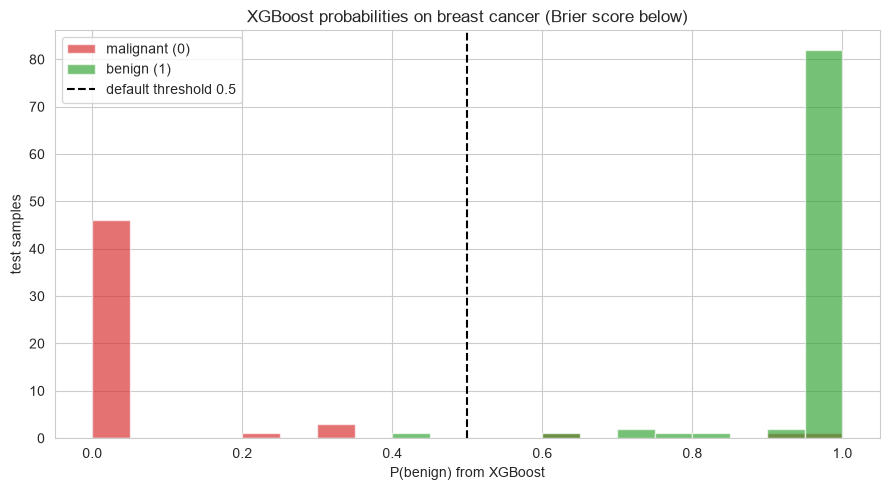

Brier score: 0.0231  (0 = perfect probabilities, 0.25 = uninformed)

💡 Same reading as notebook 08's Example 1, one engine deeper: the p = 0.5 cut
   is a choice. For a screening task a clinic might act at P(malignant) > 0.2,
   trading false alarms for fewer missed cancers - priced by the confusion matrix.


In [20]:
# ...and the probability read: where do the two classes' scores land?
proba_bc10 = final_bc10.predict_proba(Xbc10_te)[:, 1]      # P(benign)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(proba_bc10[ybc10_te == 0], bins=np.linspace(0, 1, 21), alpha=0.65,
        color="#d62728", label="malignant (0)")
ax.hist(proba_bc10[ybc10_te == 1], bins=np.linspace(0, 1, 21), alpha=0.65,
        color="#2ca02c", label="benign (1)")
ax.axvline(0.5, color="k", ls="--", lw=1.5, label="default threshold 0.5")
ax.set_xlabel("P(benign) from XGBoost")
ax.set_ylabel("test samples")
ax.set_title("XGBoost probabilities on breast cancer (Brier score below)")
ax.legend()
plt.tight_layout()
plt.show()

brier_bc10 = brier_score_loss(ybc10_te, proba_bc10)
print(f"Brier score: {brier_bc10:.4f}  (0 = perfect probabilities, 0.25 = uninformed)")
print("\n💡 Same reading as notebook 08's Example 1, one engine deeper: the p = 0.5 cut")
print("   is a choice. For a screening task a clinic might act at P(malignant) > 0.2,")
print("   trading false alarms for fewer missed cancers - priced by the confusion matrix.")

### Example 2: Diabetes Progression (Regression)

442 patients × 10 baseline variables (the features arrive pre-standardized), target = disease progression one year out. `XGBRegressor` with an ES budget; the test read is R² and RMSE, the inspection tools are gain importances and the predictions-vs-truth picture.

early stopping saved best_iteration = 35 of 1000
test R²:   0.4652
test RMSE: 54.3792


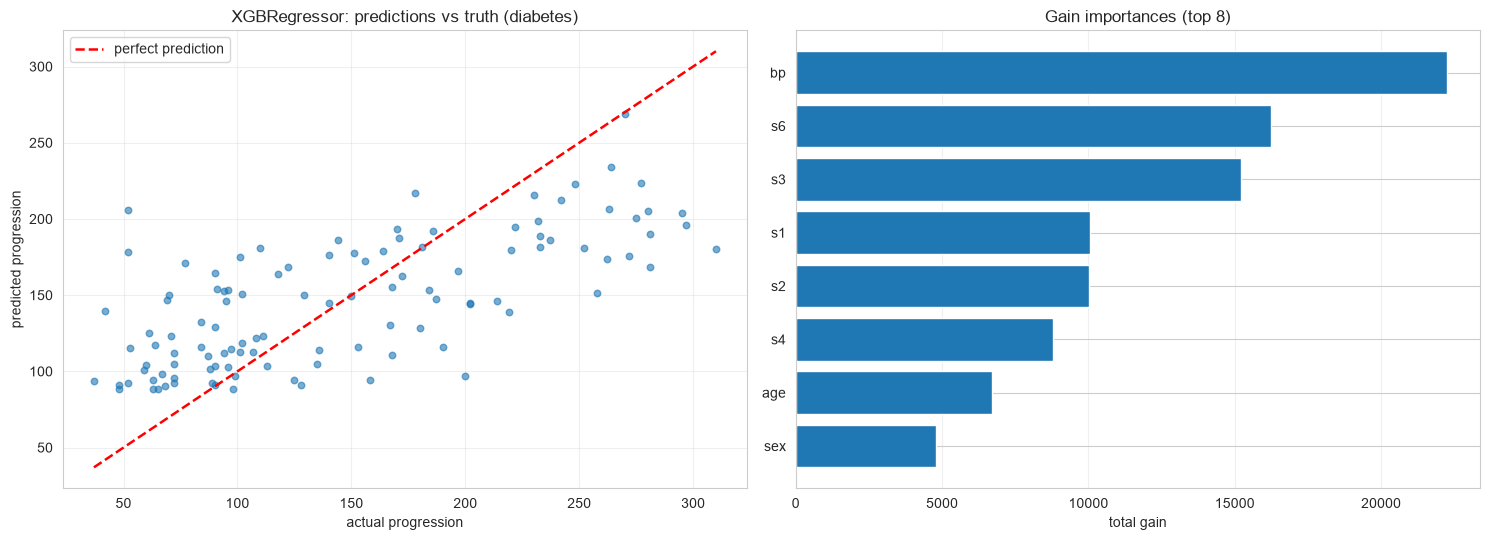


top-3 gain features: ['bmi', 's5', 'bp']

💡 The predictions clamp to the training range at the extremes - trees cannot
   extrapolate (notebook 04's warning, priced in real units here). Also visible:
   the gains ride on a few features (bmi/ltg-class signals), the clinical picture
   of a small, well-conditioned regression problem.


In [21]:
# Example 2: diabetes progression - XGBRegressor with an ES budget
diabetes10 = load_diabetes()
Xdi10 = pd.DataFrame(diabetes10.data, columns=diabetes10.feature_names)
ydi10 = diabetes10.target

Xdi10_tr, Xdi10_te, ydi10_tr, ydi10_te = train_test_split(
    Xdi10, ydi10, test_size=0.25, random_state=42
)
Xdi10_fit, Xdi10_val, ydi10_fit, ydi10_val = train_test_split(
    Xdi10_tr, ydi10_tr, test_size=0.2, random_state=42
)

final_di10 = XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=3,
    eval_metric="rmse", early_stopping_rounds=25, random_state=42,
)
final_di10.fit(Xdi10_fit, ydi10_fit, eval_set=[(Xdi10_val, ydi10_val)], verbose=False)
pred_di10 = final_di10.predict(Xdi10_te)

print(f"early stopping saved best_iteration = {final_di10.best_iteration} of 1000")
print(f"test R²:   {r2_score(ydi10_te, pred_di10):.4f}")
print(f"test RMSE: {np.sqrt(mean_squared_error(ydi10_te, pred_di10)):.4f}")

gain_di10 = pd.Series(
    final_di10.get_booster().get_score(importance_type="gain")
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].scatter(ydi10_te, pred_di10, alpha=0.6, s=22, color="#1f77b4")
lims_di = [min(ydi10_te.min(), pred_di10.min()), max(ydi10_te.max(), pred_di10.max())]
axes[0].plot(lims_di, lims_di, "r--", lw=1.8, label="perfect prediction")
axes[0].set_xlabel("actual progression")
axes[0].set_ylabel("predicted progression")
axes[0].set_title("XGBRegressor: predictions vs truth (diabetes)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].barh(gain_di10.index[::-1][:8], gain_di10.values[::-1][:8], color="#1f77b4")
axes[1].set_xlabel("total gain")
axes[1].set_title("Gain importances (top 8)")
axes[1].grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\ntop-3 gain features: {list(gain_di10.head(3).index)}")
print("\n💡 The predictions clamp to the training range at the extremes - trees cannot")
print("   extrapolate (notebook 04's warning, priced in real units here). Also visible:")
print("   the gains ride on a few features (bmi/ltg-class signals), the clinical picture")
print("   of a small, well-conditioned regression problem.")

---

## 11. Comparison with Other Algorithms

### When to Choose XGBoost vs Alternatives

| Aspect | XGBoost | sklearn GradientBoosting | HistGradientBoosting | Random Forest |
|---|---|---|---|---|
| **Leaf algebra** | $w^* = -G/(H+\lambda)$, priced by Ω | Friedman tweak on the Newton step² | Newton step (λ=0) | leaf means/votes |
| **Split criterion** | gain formula **− γ toll** | `friedman_mse` | binned log-loss/MSE | gini/entropy |
| **NaN handling** | native, learned default direction | raises | native | imputation needed |
| **Multiclass** | `softprob` (K trees/stage) | softmax deviance (K trees/stage) | `one-vs-rest` internals | vote fractions |
| **Stochasticity** | subsample / colsample_by* | subsample | subsample (+ early stopping) | bootstrap + max_features |
| **Early stopping** | constructor + `eval_set` | `n_iter_no_change` trio | `early_stopping` | none (OOB instead) |
| **Default fit on small data** | can overfit (η 0.3, depth 6) | gentler (η 0.1, depth 3) | gentle | very robust |
| **Speed at scale** | ⭐⭐⭐⭐⭐ (hist + threads/GPU) | ⭐⭐ (exact splits) | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ (parallel) |
| **Serialization** | JSON save_model | pickle-only | pickle-only | pickle-only |

² shared skeleton — see notebook 08 §6's dual-engine analysis for exactly where the two differ.

The **first three rows** are the fork: XGBoost is the only engine of the four whose *regularizer lives inside both the leaf values and the split criterion*, and the only one that learns what to do with missing values. HistGradientBoosting is its closest sklearn sibling (a binned variant with NaN support); LightGBM and CatBoost (notebooks 10–11) push the histogram/categorical line further.

### Practical Comparison

The same 5-fold CV protocol as notebooks 05/08 on three geometries. XGBoost runs `n_jobs=1` (its cores belong to the outer CV sweep).

In [22]:
bc_cmp = load_breast_cancer()
datasets_cmp = {
    "blobs (3-class)": make_blobs(n_samples=600, centers=3, cluster_std=2.0, random_state=0),
    "moons (noisy)": make_moons(n_samples=600, noise=0.25, random_state=0),
    "breast cancer": (bc_cmp.data, bc_cmp.target),
}


def fresh_engines():
    # XGBoost n_jobs=1: the core budget belongs to cross_val_score's n_jobs=-1
    return {
        "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                 n_jobs=1, random_state=0),
        "HistGradientBoosting": HistGradientBoostingClassifier(max_depth=3, random_state=0),
        "GradientBoosting (sklearn)": GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1, random_state=0),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    }


cv_cmp = StratifiedKFold(5, shuffle=True, random_state=0)
rows_cmp = []
for ds_name, (X_c, y_c) in datasets_cmp.items():
    for m_name, est_c in fresh_engines().items():
        t0 = time.perf_counter()
        scores_c = cross_val_score(est_c, X_c, y_c, cv=cv_cmp, scoring="accuracy", n_jobs=-1)
        rows_cmp.append({"model": m_name, "dataset": ds_name,
                         "mean": scores_c.mean(), "std": scores_c.std(),
                         "cv time (s)": time.perf_counter() - t0})

df_cmp = pd.DataFrame(rows_cmp).pivot(index="model", columns="dataset", values="mean")
df_cmp = df_cmp[["blobs (3-class)", "moons (noisy)", "breast cancer"]]
print(df_cmp.round(3).to_string())

xgb_row = df_cmp.loc["XGBoost"]
gb_row = df_cmp.loc["GradientBoosting (sklearn)"]
print(f"\nXGBoost beats its sklearn ancestor on "
      f"{int((xgb_row > gb_row).sum())} of 3 geometries (mean CV accuracy)")
times_cmp = pd.DataFrame(rows_cmp).groupby("model")["cv time (s)"].mean().round(2)
print(times_cmp.to_string())
print("\n💡 The margins are small and geometry-dependent - which is the honest summary:")
print("   the second-order machinery and the split toll buy accuracy on real data, while")
print("   a well-tuned HistGB often lands within noise of XGBoost on these sizes.")

dataset                     blobs (3-class)  moons (noisy)  breast cancer
model                                                                    
GradientBoosting (sklearn)            0.692          0.928          0.965
HistGradientBoosting                  0.672          0.925          0.972
Random Forest                         0.637          0.925          0.967
XGBoost                               0.675          0.937          0.974

XGBoost beats its sklearn ancestor on 2 of 3 geometries (mean CV accuracy)
model
GradientBoosting (sklearn)    0.36
HistGradientBoosting          0.18
Random Forest                 0.54
XGBoost                       0.08

💡 The margins are small and geometry-dependent - which is the honest summary:
   the second-order machinery and the split toll buy accuracy on real data, while
   a well-tuned HistGB often lands within noise of XGBoost on these sizes.


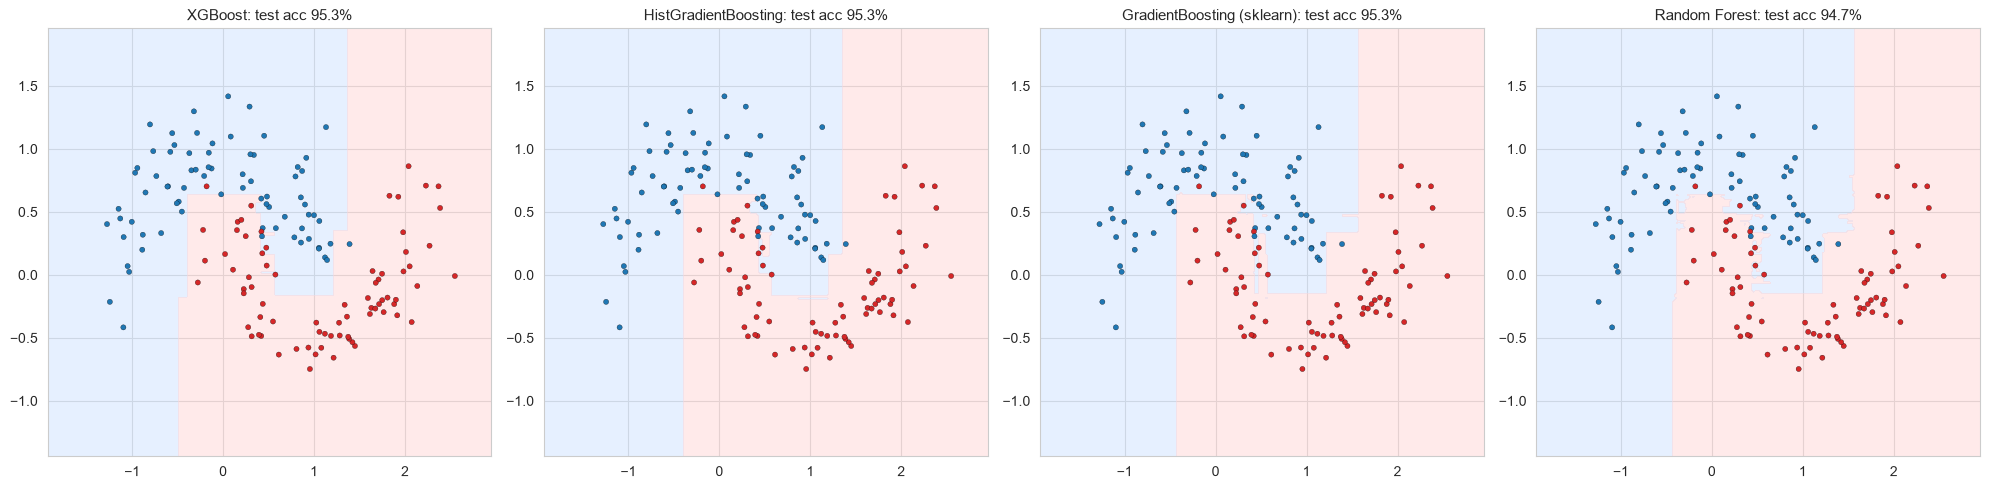


💡 Boosting's boundary is the smoothest of the tree models - and XGBoost's regularized
   leaves keep it smooth without going island-y. The forest is blocky in a different
   way (deep votes); the single-family HistGB lands almost on top of XGBoost here.


In [23]:
X_b11, y_b11 = make_moons(n_samples=500, noise=0.22, random_state=42)
Xb11_tr, Xb11_te, yb11_tr, yb11_te = train_test_split(X_b11, y_b11, test_size=0.3,
                                                      stratify=y_b11, random_state=42)
families_b11 = fresh_engines()

pad_b = 0.4
xx_b, yy_b = np.meshgrid(
    np.linspace(X_b11[:, 0].min() - pad_b, X_b11[:, 0].max() + pad_b, 250),
    np.linspace(X_b11[:, 1].min() - pad_b, X_b11[:, 1].max() + pad_b, 250),
)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name_b, est_b) in zip(axes, families_b11.items()):
    est_b.fit(Xb11_tr, yb11_tr)
    Z_b = est_b.predict(np.c_[xx_b.ravel(), yy_b.ravel()]).reshape(xx_b.shape)
    ax.contourf(xx_b, yy_b, Z_b, levels=[-0.5, 0.5, 1.5], colors=["#cfe2ff", "#ffd6d6"], alpha=0.5)
    ax.scatter(Xb11_te[:, 0], Xb11_te[:, 1], c=np.where(yb11_te == 1, "#d62728", "#1f77b4"),
               s=14, edgecolors="k", linewidths=0.2)
    ax.set_title(f"{name_b}: test acc {est_b.score(Xb11_te, yb11_te):.1%}", fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Boosting's boundary is the smoothest of the tree models - and XGBoost's regularized")
print("   leaves keep it smooth without going island-y. The forest is blocky in a different")
print("   way (deep votes); the single-family HistGB lands almost on top of XGBoost here.")

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - **Chen, T., & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System."** *KDD '16*: the regularized second-order objective, the weighted-quantile split proposal, sparsity-aware splits, and the systems engineering
   - Friedman, J. H. (2001). "Greedy Function Approximation: A Gradient Boosting Machine." *Annals of Statistics*, 29(5): the skeleton (notebook 08)
   - Friedman, J. H. (2002). "Stochastic Gradient Boosting." *Computational Statistics & Data Analysis*, 38(4): row subsampling (`subsample`)
   - Mason, L., Baxter, J., Bartlett, P., & Frean, M. (1999). "Boosting Algorithms as Gradient Descent in Function Space." *NIPS 12*: the functional-gradient view
2. **The Library Lineage (notebooks 10–11)**:
   - Ke, G. et al. (2017). "LightGBM: A Highly Efficient Gradient Boosting Decision Tree." *NeurIPS 30*: the histogram/leaf-wise line
   - Prokhorenkova, L. et al. (2018). "CatBoost: Unbiased Boosting with Categorical Features." *NeurIPS 31*: ordered boosting, native categoricals
3. **Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, Chapter 10 (Boosting and Additive Trees)
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*, Chapter 8.2 (Boosting)

### 🌐 Online Resources

- [XGBoost parameter reference](https://xgboost.readthedocs.io/en/stable/parameter.html) — every parameter above, for the exact pinned version
- [Introduction to Boosted Trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html) — the tutorial behind §2's derivation
- [Using the Scikit-Learn Estimator Interface](https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html) — ES-in-CV guidance, `n_jobs` advice
- [Prediction page](https://xgboost.readthedocs.io/en/stable/prediction.html) — `iteration_range` and the native/sklearn ES inconsistency note
- [Categorical data guide](https://xgboost.readthedocs.io/en/stable/categorical.html)
- [StatQuest: XGBoost Parts 1–2](https://www.youtube.com/watch?v=OtD8wVaFm6E) — the leaf-value/gain formulas, drawn

### 📊 Key Concepts to Master

- **The regularized objective**: $\Omega = \gamma T + \tfrac12\lambda\sum w_j^2$ prices both the shape and the values
- **Second-order leaf values**: $w^* = -G/(H+\lambda)$ — the twin's Newton step (λ=0) plus smoothing
- **The gain formula**: $\tfrac12\big[\tfrac{G_L^2}{H_L+\lambda} + \tfrac{G_R^2}{H_R+\lambda} - \tfrac{(G_L+G_R)^2}{H_L+H_R+\lambda}\big] - \gamma$ — every split is priced
- **Sparsity-aware splits**: the learned default direction; NaN in X is information, NaN in y is an error
- **Histogram splits**: `hist` bins candidates (`max_bin`); split cost independent of n
- **Early stopping**: constructor `early_stopping_rounds` + `eval_set`; wrapper predict auto-uses `best_iteration`; native predict needs `iteration_range`
- **Four importance types**: gain / cover / weight / total_* — read more than one before acting

### 🔗 Related Notebooks and Repository Files

- `08_gradient_boosting.ipynb` — the skeleton this notebook regularizes; read its §5–§6 first
- `04_random_forest.ipynb` — the bagging counterpart (variance vs bias)
- `03_decision_trees.ipynb` — the base learner
- `10_lightgbm.ipynb`, `11_catboost.ipynb` — the next two library chapters (hist/categorical)
- `16_ensemble_methods.ipynb` — where XGBoost members can be stacked with others
- `src/models/ensemble_models.py` — `GradientBoostingClassifierScratch`, the family twin used in §5
- `tests/models/test_ensemble_models.py` — the behavioral contract of the twin

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: XGBoost = gradient boosting + a second-order Taylor expansion + an explicit regularizer Ω; every leaf value ($w^* = -G/(H+\lambda)$) and every split (gain − γ) is priced, not just fitted
2. **Math**: the bridge to notebook 08 is exact — the twin's Newton leaf $\sum g/\sum h$ is XGBoost's leaf at λ = 0; the sign conventions are translations, not disagreements
3. **Assumptions**: no scaling, native NaN routing is a feature (except in the label), loss must match the task, labels the wrapper can sort
4. **Implementation**: the family twin carries the shared skeleton; λ was hand-built in-notebook on the twin's trees; the histogram machinery stays XGBoost's compiled territory
5. **Interfaces**: the sklearn wrapper (constructor `eval_metric`/`early_stopping_rounds`, auto-`best_iteration` predictions) and the native API (`DMatrix`, `xgb.train`, `EarlyStopping` callback, `pred_contribs`)
6. **Hyperparameters**: η × B first, depth/min_child_weight second, samplers third, λ/α/γ fourth — all on log grids
7. **Practice**: ES as a budget everywhere, importances verified across types, probabilities checked with a Brier read, `n_jobs` pinned where the parallelism actually lives

### When to Use XGBoost

✅ **Use when**:
- tabular accuracy matters and tuning is on the table
- the data has NaNs, mixed scales, or outliers that tree logic absorbs natively
- speed at scale matters: histogram splits, threads, GPU, JSON serialization
- you want decision-grade engineering: ES, constraints, per-sample contributions

❌ **Avoid when**:
- the dataset is tiny (< ~100 rows) — regularized boosting needs rows
- extrapolation is required — trees clamp (§10 Example 2 shows it in real units)
- deployable interpretability outranks accuracy — a linear model is the honest tool (notebooks 01–02)
- text/image-adjacent unstructured data — representation learners own that world (notebook 17)

### Best Practices Checklist

- ✅ start at `n_estimators=200, learning_rate=0.1, max_depth=3` (small data) or defaults + ES (large data)
- ✅ log grids for η/γ/λ; CV on training data only; the test set reports once
- ✅ early stop on a carved validation slice; retrain on the full training set with the chosen knobs
- ✅ `n_jobs=1` for XGBoost inside parallel sklearn sweeps
- ✅ read importance types together (gain + weight + cover), verify with permutation importance
- ✅ Brier/reliability before decisionary use of probabilities
- ✅ `save_model` in JSON; document the pinned version

### Critical Requirements

1. **Consecutive integer class labels** for the wrapper (0..K−1)
2. **A loss and metric that match the task** — the objective is not negotiable
3. **Enough rows per leaf** for the second-order statistics and the regularizer to mean something
4. **A validation slice** for early stopping — ES without `eval_set` is a no-op

### Advantages vs Disadvantages

**Advantages:**
- ✅ the strongest practical accuracy record on structured data for a decade
- ✅ regularized where it counts: leaf values *and* split decisions are priced
- ✅ native NaN handling; mixed scales and outliers absorbed
- ✅ fast at scale (hist, threads, GPU) and portable (JSON)
- ✅ a mature ecosystem: constraints, contributions, early stopping, rankers

**Disadvantages:**
- ❌ large default hyperparameters tuned the wrong way for small data
- ❌ sequential training — stages cannot be parallelized (the forest's trick)
- ❌ no extrapolation; trees clamp to the training range
- ❌ probabilities need a verification/calibration step on decision-critical use
- ❌ interpretability is post-hoc (importances/contributions), not structural

### Unique Characteristic: The Priced Ensemble

XGBoost is the boosted tree that *charges tolls*. A split must repay γ in objective gain; a leaf must justify its weight against $\tfrac12\lambda w^2$; a stage must beat the validation curve or the ensemble stops. That pricing — visible in one formula, $w^* = -G/(H+\lambda)$, and one threshold, the γ toll — is what separates "powerful with discipline" from "powerful".

### Next Steps

1. **Practice** the recipes on your own data: ES budget first, then the tuning order of §7
2. **Diagnose** with `evals_result()` curves, the four importance types, and `pred_contribs` on suspicious rows
3. **Compare** against HistGradientBoosting and a random forest on the same folds (§11's harness)
4. **Read** notebooks 10–11 next: LightGBM (the histogram line) and CatBoost (native categoricals)
5. **Explore** `src/models/ensemble_models.py` — the tutorial twin whose Newton leaf is λ-regularized boosting at λ = 0

---

**Congratulations!** You can now derive the leaf values, price a split against the γ toll, wire early stopping in both interfaces, and know exactly when compiled XGBoost is worth its knobs. 🎯🎉

**Remember**: the model is the sum of priced leaves. Small steps, checked metrics, honest validation - and let the tolls do the pruning.